In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import xarray as xr
import pandas as pd

PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ERA5_monthly/*/*nc"

def preprocess(ds):
    if "valid_time" in ds.dims or "valid_time" in ds.coords:
        ds = ds.rename({"valid_time": "time"})
    return ds

ds = xr.open_mfdataset(
    PATH,
    combine="nested",
   # concat_dim="station",
    preprocess=preprocess,
    chunks={"time": 500},
    parallel=True
)

In [3]:
ds_grid = ds

In [4]:
from scipy.interpolate import griddata
import numpy as np
import xarray as xr

# 1D spatial coordinates
lon = ds_grid.longitude.values
lat = ds_grid.latitude.values

# 2D target grid
lon2d, lat2d = np.meshgrid(lon, lat)

# (N, 2) coordinate pairs for one spatial slice
points = np.column_stack([lon2d.ravel(), lat2d.ravel()])

def fill_na_spatial_over_time(da, method="nearest"):
    """
    Fill NaNs in a DataArray with dims (time, latitude, longitude)
    by interpolating each time slice independently in space.
    """
    filled_list = []

    for t in range(da.sizes["time"]):
        values_2d = da.isel(time=t).values          # shape: (lat, lon)
        values_1d = values_2d.ravel()

        mask = ~np.isnan(values_1d)

        # if entire slice is NaN, keep it as NaN
        if mask.sum() == 0:
            filled_2d = np.full_like(values_2d, np.nan, dtype=float)
        else:
            filled_2d = griddata(
                points[mask],
                values_1d[mask],
                (lon2d, lat2d),
                method=method
            )

        filled_list.append(filled_2d)

    filled_array = np.stack(filled_list, axis=0)  # (time, lat, lon)

    return xr.DataArray(
        filled_array,
        coords=da.coords,
        dims=da.dims,
        name=f"{da.name}_filled"
    )

# Fill variables
sst_interp_da = fill_na_spatial_over_time(ds_grid["sst"], method="nearest")
swh_interp_da = fill_na_spatial_over_time(ds_grid["swh"], method="nearest")
mwd_interp_da = fill_na_spatial_over_time(ds_grid["mwd"], method="nearest")
mwp_interp_da = fill_na_spatial_over_time(ds_grid["mwp"], method="nearest")
wsk_interp_da = fill_na_spatial_over_time(ds_grid["wsk"], method="nearest")

ds_grid["sst"] = fill_na_spatial_over_time(ds_grid["sst"], method="nearest")
ds_grid["swh"] = fill_na_spatial_over_time(ds_grid["swh"], method="nearest")
ds_grid["mwd"] = fill_na_spatial_over_time(ds_grid["mwd"], method="nearest")
ds_grid["mwp"] = fill_na_spatial_over_time(ds_grid["mwp"], method="nearest")
ds_grid["wsk"] = fill_na_spatial_over_time(ds_grid["wsk"], method="nearest")

In [5]:
mwd_interp_da = fill_na_spatial_over_time(ds_grid["mwd"], method="nearest")
mwp_interp_da = fill_na_spatial_over_time(ds_grid["mwp"], method="nearest")
wsk_interp_da = fill_na_spatial_over_time(ds_grid["wsk"], method="nearest")
ds_grid["mwd"] = fill_na_spatial_over_time(ds_grid["mwd"], method="nearest")
ds_grid["mwp"] = fill_na_spatial_over_time(ds_grid["mwp"], method="nearest")
ds_grid["wsk"] = fill_na_spatial_over_time(ds_grid["wsk"], method="nearest")

In [6]:
ds= ds_grid

In [7]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd
import cartopy.io.shapereader as shpreader
from shapely.geometry import box, LineString, MultiLineString, Point
from shapely.ops import unary_union, linemerge
from shapely.prepared import prep

# --------------------------------------------------
# 1. Domain
# --------------------------------------------------
lon_min, lon_max = -11.5, 11
lat_min, lat_max = 47.0, 63
domain = box(lon_min, lat_min, lon_max, lat_max)

# --------------------------------------------------
# 2. Load and clip coastline
# --------------------------------------------------
coast_shp = shpreader.natural_earth(
    resolution="10m",
    category="physical",
    name="coastline"
)

reader = shpreader.Reader(coast_shp)
coast_geoms = list(reader.geometries())

clipped = []
for geom in coast_geoms:
    inter = geom.intersection(domain)
    if not inter.is_empty:
        clipped.append(inter)

merged = unary_union(clipped)
merged = linemerge(merged)

# --------------------------------------------------
# 3. Sample coastline points
# --------------------------------------------------
def sample_linestring(ls, spacing=0.25):
    if ls.length == 0:
        return []

    distances = np.arange(0, ls.length, spacing)
    if len(distances) == 0 or distances[-1] < ls.length:
        distances = np.append(distances, ls.length)

    pts = [ls.interpolate(d) for d in distances]
    return [(p.x, p.y) for p in pts]

def collect_points(geom, spacing=0.25):
    pts = []

    if isinstance(geom, LineString):
        pts.extend(sample_linestring(geom, spacing=spacing))

    elif isinstance(geom, MultiLineString):
        for part in geom.geoms:
            pts.extend(sample_linestring(part, spacing=spacing))

    else:
        try:
            for g in geom.geoms:
                pts.extend(collect_points(g, spacing=spacing))
        except AttributeError:
            pass

    return pts

all_points = collect_points(merged, spacing=0.25)

# Remove duplicates
rounded_points = [(round(lon, 6), round(lat, 6)) for lon, lat in all_points]
unique_points = list(dict.fromkeys(rounded_points))

df_points = pd.DataFrame(unique_points, columns=["lon", "lat"])
df_points.insert(0, "point_id", np.arange(1, len(df_points) + 1))

# coastline points
coast_lon = df_points["lon"].to_numpy()
coast_lat = df_points["lat"].to_numpy()
point_id = df_points["point_id"].to_numpy()

# valid wave cells from swh
wave_mask = ds["swh"].notnull().any("time")

lon2d, lat2d = np.meshgrid(ds.longitude.values, ds.latitude.values)

wave_lon = lon2d[wave_mask.values]
wave_lat = lat2d[wave_mask.values]

wave_tree = cKDTree(np.column_stack([wave_lon, wave_lat]))
wave_dist, wave_idx = wave_tree.query(np.column_stack([coast_lon, coast_lat]), k=1)

matched_wave_lon = wave_lon[wave_idx]
matched_wave_lat = wave_lat[wave_idx]

wave_match_df = df_points.copy()
wave_match_df["wave_lon"] = matched_wave_lon
wave_match_df["wave_lat"] = matched_wave_lat
wave_match_df["wave_distance_deg"] = wave_dist
# --- wave-constrained variables ---
wave_vars = ["swh", "mwd", "mwp", "wsk", "sst"]

wave_subset = ds[wave_vars].sel(
    longitude=xr.DataArray(matched_wave_lon, dims="point", coords={"point": point_id}),
    latitude=xr.DataArray(matched_wave_lat, dims="point", coords={"point": point_id}),
)

# keep matched coordinates under explicit names
wave_subset = wave_subset.assign_coords(
    point=("point", point_id),
    coast_lon=("point", coast_lon),
    coast_lat=("point", coast_lat),
    wave_lon=("point", matched_wave_lon),
    wave_lat=("point", matched_wave_lat),
    wave_distance_deg=("point", wave_dist),
)

# remove conflicting xarray selection coords
wave_subset = wave_subset.drop_vars(["longitude", "latitude"])


# --- direct variables ---
direct_vars = ["u10", "v10", "msl", "tp", "d2m", "sp", "t2m"]   # example

direct_subset = ds[direct_vars].sel(
    longitude=xr.DataArray(coast_lon, dims="point", coords={"point": point_id}),
    latitude=xr.DataArray(coast_lat, dims="point", coords={"point": point_id}),
    method="nearest"
)

# recover actual matched direct-grid coordinates from the selection result
direct_lon = direct_subset["longitude"].values
direct_lat = direct_subset["latitude"].values

direct_subset = direct_subset.assign_coords(
    point=("point", point_id),
    direct_lon=("point", direct_lon),
    direct_lat=("point", direct_lat),
)

direct_subset = direct_subset.drop_vars(["longitude", "latitude"])


# --- merge safely ---
final_subset = xr.merge([wave_subset, direct_subset])

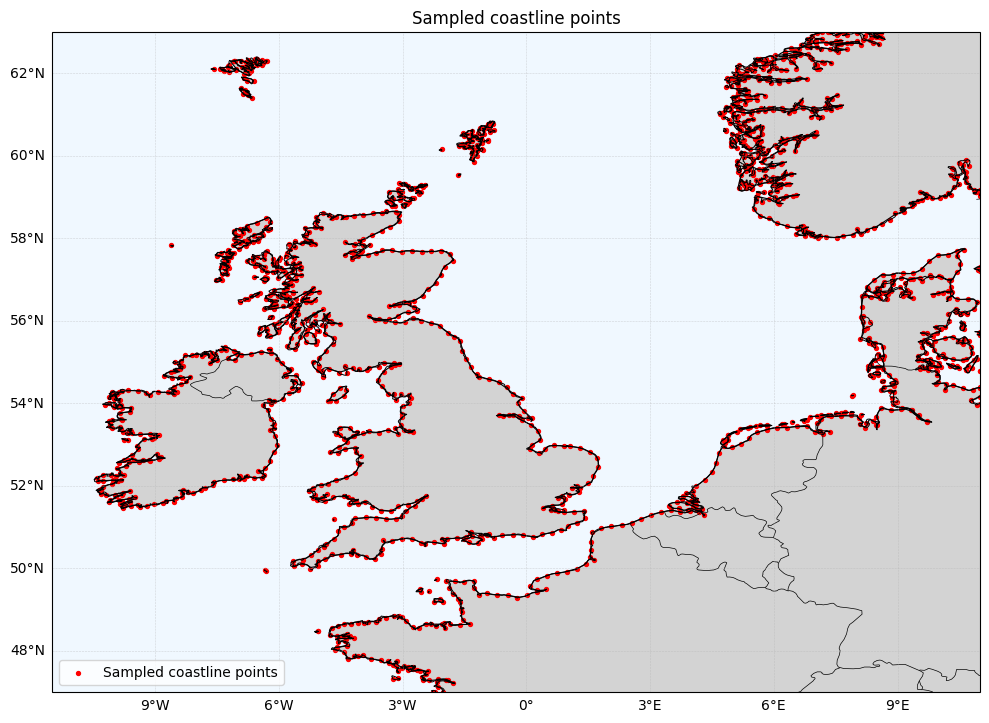

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# domain
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# background
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# sampled coastline points
ax.scatter(
    df_points["lon"],
    df_points["lat"],
    s=8,
    color="red",
    transform=ccrs.PlateCarree(),
    label="Sampled coastline points"
)

# optional: plot the clipped coastline geometry too
try:
    ax.add_geometries(
        [merged],
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=0.7
    )
except Exception:
    pass

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.set_title("Sampled coastline points")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

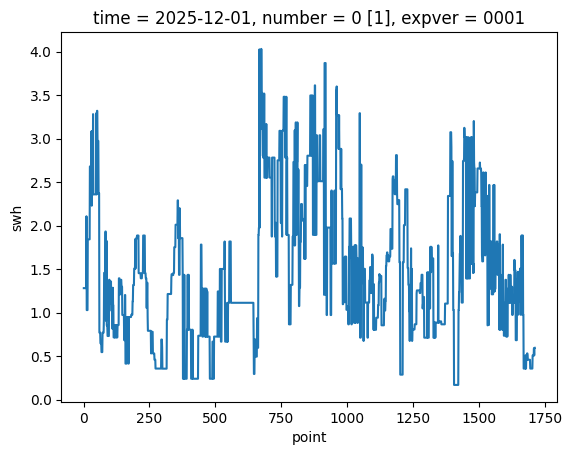

In [9]:
final_subset.swh.isel(time=1822).plot()

In [10]:
import pandas as pd
import xarray as xr

# make sure these are coordinates
final_subset = final_subset.set_coords(["direct_lat", "direct_lon"])

# build lookup table: one row per point
cell_index = pd.DataFrame({
    "point": final_subset["point"].values,
    "latitude": final_subset["direct_lat"].values,
    "longitude": final_subset["direct_lon"].values,
    "wave_distance_deg": final_subset["wave_distance_deg"].values,
})

# keep one point per direct grid cell
# choose the point with the smallest wave-match distance
keep_points = (
    cell_index
    .sort_values("wave_distance_deg")
    .drop_duplicates(subset=["latitude", "longitude"], keep="first")
    ["point"]
    .to_numpy()
)

# subset to unique cells only
final_subset_unique = final_subset.sel(point=keep_points)

# rename direct coords to standard spatial names
final_subset_unique = final_subset_unique.rename({
    "direct_lat": "latitude",
    "direct_lon": "longitude",
})

# make lat/lon proper coordinates
final_subset_unique = final_subset_unique.set_coords(["latitude", "longitude"])

# replace point dimension by (latitude, longitude)
final_subset_unique = (
    final_subset_unique
    .set_index(point=["latitude", "longitude"])
    .unstack("point")
)

# optional: order dimensions nicely
final_subset_unique = final_subset_unique.transpose("time", "latitude", "longitude")

print(final_subset_unique)

<xarray.Dataset> Size: 658MB
Dimensions:            (latitude: 61, longitude: 87, time: 1824)
Coordinates:
  * latitude           (latitude) float64 488B 47.0 47.25 47.5 ... 61.75 62.0
  * longitude          (longitude) float64 696B -10.5 -10.25 ... 10.75 11.0
  * time               (time) datetime64[ns] 15kB 1950-01-01 ... 2025-12-01T0...
    number             int64 8B 0
    expver             (time) object 15kB dask.array<chunksize=(96,), meta=np.ndarray>
    coast_lon          (latitude, longitude) float64 42kB nan nan ... nan nan
    coast_lat          (latitude, longitude) float64 42kB nan nan ... nan nan
    wave_lon           (latitude, longitude) float64 42kB nan nan ... nan nan
    wave_lat           (latitude, longitude) float64 42kB nan nan ... nan nan
    wave_distance_deg  (latitude, longitude) float64 42kB nan nan ... nan nan
Data variables:
    swh                (time, latitude, longitude) float64 77MB nan nan ... nan
    mwd                (time, latitude, longitude) 

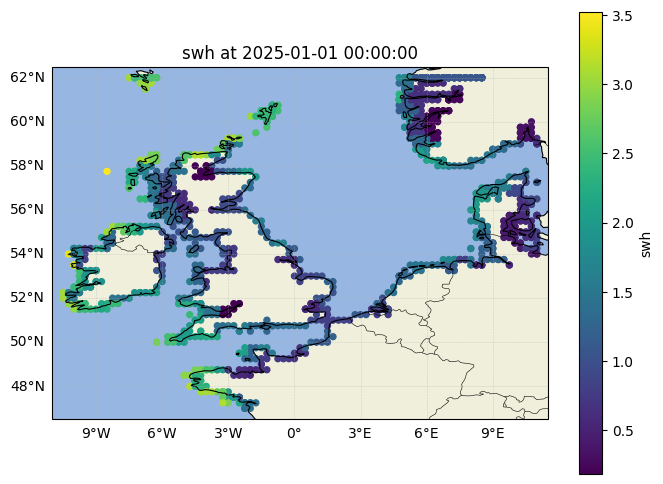

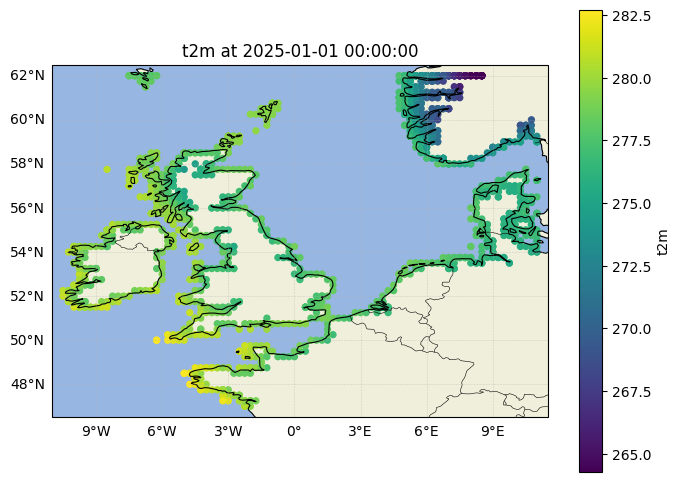

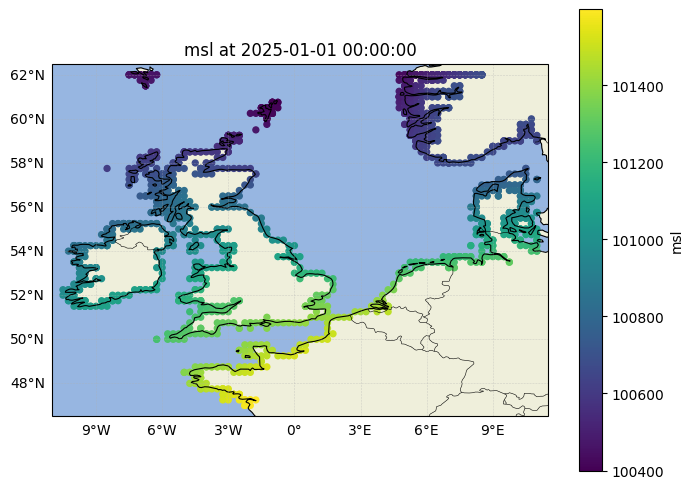

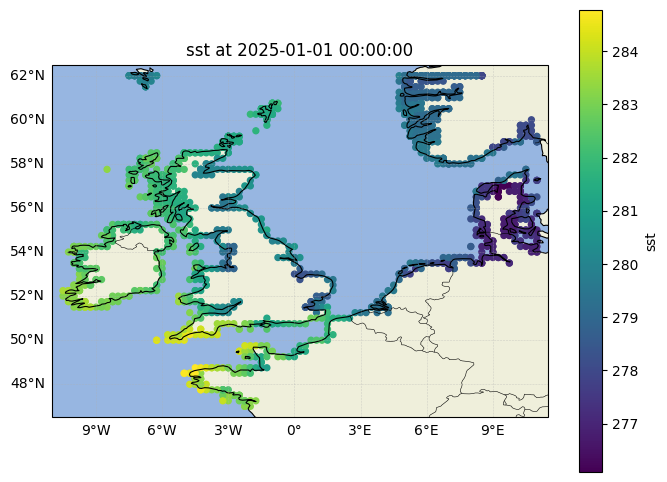

In [11]:
# rename direct coords to standard spatial names
final_subset = final_subset.rename({
    "direct_lat": "latitude",
    "direct_lon": "longitude",
})
df_coast_monthly = final_subset.to_dataframe().reset_index()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# make sure time is datetime
df_coast_monthly["time"] = pd.to_datetime(df_coast_monthly["time"])

# choose one timestamp
t = pd.Timestamp("2025-01-01 00:00:00")

# variables to plot
vars_to_plot = ["swh", "mwd", "mwp", "wsk", "u10", "v10", "msl", "tp", "d2m", "sp", "t2m", "sst"]

# subset for one time
df_t = df_coast_monthly[df_coast_monthly["time"] == t].copy()


def plot_spatial_variable(df_t, var, lon_col="longitude", lat_col="latitude",
                          title=None, figsize=(8, 8), s=18):
    d = df_t[[lon_col, lat_col, var]].dropna().copy()

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.OCEAN, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    if len(d) > 0:
        pad = 0.5
        ax.set_extent([
            d[lon_col].min() - pad, d[lon_col].max() + pad,
            d[lat_col].min() - pad, d[lat_col].max() + pad
        ], crs=ccrs.PlateCarree())

        sc = ax.scatter(
            d[lon_col], d[lat_col],
            c=d[var],
            s=s,
            transform=ccrs.PlateCarree()
        )
        plt.colorbar(sc, ax=ax, shrink=0.75, label=var)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title or f"{var} at {pd.Timestamp(df_t['time'].iloc[0])}")
    plt.show()
    
plot_spatial_variable(df_t, "swh")
plot_spatial_variable(df_t, "t2m")
plot_spatial_variable(df_t, "msl")
plot_spatial_variable(df_t, "sst")

https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means?tab=download

In [12]:
df_bi = df_coast_monthly.rename(columns={"point":"station"})

In [13]:
df_bi["wind_magnitude"] = np.sqrt((df_bi["u10"]**2 )* (df_bi["v10"]**2))
df_bi["wind_dir"] = np.degrees(np.arctan2(df_bi["u10"], df_bi["v10"])) % 360
df_bi["u10_abs"] = df_bi["u10"].abs()
df_bi["v10_abs"] = df_bi["v10"].abs()
df_bi["wind_wave_diff"] =  df_bi["mwd"] - df_bi["wind_dir"]
df_bi["wind_wave_alignment"] =  np.cos(df_bi["wind_dir"] - df_bi["mwd"])
rho_air = 1.225      # kg m-3
Cd = 1.3e-3          # neutral drag coefficient
df_bi["tau_u"] = rho_air * Cd * df_bi["wind_magnitude"] * df_bi["u10"]
df_bi["tau_u_abs"] = df_bi["tau_u"].abs()
df_bi["tau_v"] = rho_air * Cd * df_bi["wind_magnitude"]  * df_bi["v10"]
df_bi["tau_v_abs"] = df_bi["tau_v"].abs()
df_bi["tau_mag"] = rho_air * Cd * df_bi["wind_magnitude"] **2

In [149]:
df_bi.columns

Index(['time', 'station', 'swh', 'mwd', 'mwp', 'wsk', 'sst', 'number',
       'expver', 'coast_lon', 'coast_lat', 'wave_lon', 'wave_lat',
       'wave_distance_deg', 'u10', 'v10', 'msl', 'tp', 'd2m', 'sp', 't2m',
       'longitude', 'latitude', 'wind_magnitude', 'wind_dir', 'u10_abs',
       'v10_abs', 'wind_wave_diff', 'wind_wave_alignment', 'tau_u',
       'tau_u_abs', 'tau_v', 'tau_v_abs', 'tau_mag'],
      dtype='object')

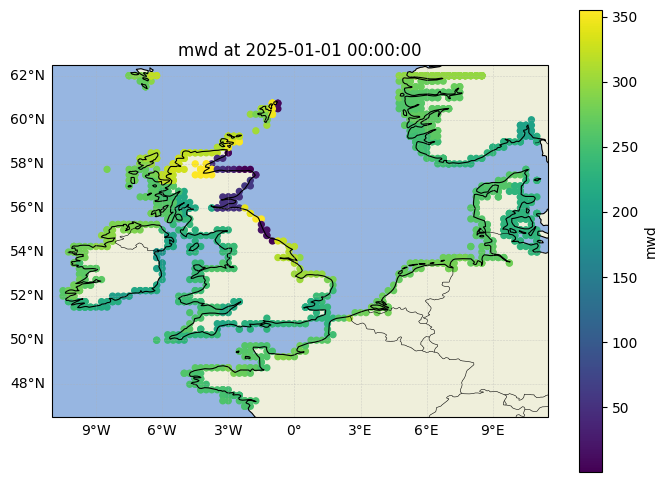

In [144]:
df_t = df_bi[df_bi["time"] == t].copy()
plot_spatial_variable(df_t, "mwd")

# coastal alignment

In [14]:
import pandas as pd

df = df_bi.copy()

# Ensure datetime
df['time'] = pd.to_datetime(df['time'])

# Filter years
df = df[(df['time'].dt.year >= 1980) & (df['time'].dt.year <= 2020)]

# Keep only numeric columns (these are valid for max)
num_cols = df.select_dtypes(include='number').columns.tolist()

exclude_cols = ['expver', 'number', 'coast_lon', 'coast_lat', 'wind_dir', 'mwd']
num_cols = [c for c in num_cols if c not in exclude_cols]

# Add year column
df['year'] = df['time'].dt.year

station_meta = (
    df[['station', 'latitude', 'longitude']]
    .dropna(subset=['latitude', 'longitude'])
    .drop_duplicates(subset='station')
)

annual_max = (
    df.groupby(['station', 'year'])[num_cols]
      .max()
      #.reset_
      # 
      # index()
)

annual_max= annual_max.drop(columns="station")

station_stats = (
    annual_max.reset_index().groupby('station')[num_cols]
    .agg(['mean', 'std', 'max'])
)

# Flatten column names
station_stats.columns = [
    f"{var}_am_{stat}" for var, stat in station_stats.columns
]

station_stats = station_stats.reset_index()

In [15]:
import numpy as np
import pandas as pd

def circular_mean(deg):
    deg = deg.dropna()
    if len(deg) == 0:
        return np.nan
    rad = np.deg2rad(deg)
    mean_ang = np.arctan2(np.sin(rad).mean(), np.cos(rad).mean())
    return np.mod(np.rad2deg(mean_ang), 360)

def circular_std(deg):
    deg = deg.dropna()
    if len(deg) == 0:
        return np.nan
    rad = np.deg2rad(deg)
    R = np.sqrt(np.sin(rad).mean()**2 + np.cos(rad).mean()**2)
    if R <= 0:
        return np.nan
    return np.rad2deg(np.sqrt(-2 * np.log(R)))

# ensure datetime and year filter
df = df_bi.copy()
df['time'] = pd.to_datetime(df['time'])
df = df[(df['time'].dt.year >= 1980) & (df['time'].dt.year <= 2020)]

# annual circular stats per station-year
df['year'] = df['time'].dt.year

annual_dir = (
    df.groupby(['station', 'year'])
      .agg({
          'wind_dir': [circular_mean, circular_std],
          'mwd': [circular_mean, circular_std],
      })
)

annual_dir.columns = [
    'wind_dir_mean', 'wind_dir_std',
    'mwd_mean', 'mwd_std'
]
annual_dir = annual_dir.reset_index()

# average those annual stats across all years for each station
dir_stats = (
    annual_dir.groupby('station')
    .agg({
        'wind_dir_mean': 'mean',
        'wind_dir_std': 'mean',
        'mwd_mean': 'mean',
        'mwd_std': 'mean',
    })
    .reset_index()
)

# rename to match existing station_stats columns
dir_stats = dir_stats.rename(columns={
    'wind_dir_mean': 'wind_dir_am_mean',
    'wind_dir_std': 'wind_dir_am_std',
    'mwd_mean': 'mwd_am_mean',
    'mwd_std': 'mwd_am_std',
})

# replace only these columns in station_stats
station_stats = station_stats.set_index('station')
dir_stats = dir_stats.set_index('station')

station_stats['wind_dir_am_mean'] = dir_stats['wind_dir_am_mean']
station_stats['wind_dir_am_std'] = dir_stats['wind_dir_am_std']
station_stats['mwd_am_mean'] = dir_stats['mwd_am_mean']
station_stats['mwd_am_std'] = dir_stats['mwd_am_std']

# remove max columns for directional variables if they exist
station_stats = station_stats.drop(
    columns=['wind_dir_am_max', 'mwd_am_max'],
    errors='ignore'
)

station_stats = station_stats.reset_index()

In [16]:
station_stats["mwd"] = station_stats["mwd_am_mean"]
station_stats["wind_dir"] = station_stats["wind_dir_am_mean"]
station_stats = station_stats.merge(
    station_meta,
    on='station',
    how='left'
)

In [ ]:
#df_bi = df_bi.groupby('station').mean(numeric_only=True).reset_index()

In [17]:
df_bi = station_stats

In [18]:
df_bi = df_bi.rename(columns={"latitude":"lat"})
df_bi = df_bi.rename(columns={"longitude":"lon"})

In [19]:
df_bi.to_csv("df_bi_intermittedly.csv")

In [20]:
df_bi = pd.read_csv("df_bi_intermittedly.csv")

In [21]:
import numpy as np
import pandas as pd
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import unary_union, nearest_points

# --------------------------
# helpers
# --------------------------
def bearing_deg(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.rad2deg(np.arctan2(x, y)) + 360) % 360

def ang_diff_deg(a, b):
    return (a - b + 180) % 360 - 180

def local_tangent_bearing(line, p_near):
    if not isinstance(line, LineString) or line.length == 0:
        return np.nan
    d0 = line.project(p_near)
    step = max(line.length * 0.02, 0.0005)
    d1 = np.clip(d0 - step, 0, line.length)
    d2 = np.clip(d0 + step, 0, line.length)
    p1 = line.interpolate(d1)
    p2 = line.interpolate(d2)
    return bearing_deg(p1.x, p1.y, p2.x, p2.y)

def tangent_bearing_near(coast_geom, lon, lat, radius_deg):
    p = Point(lon, lat)
    local = coast_geom.intersection(p.buffer(radius_deg))
    if local.is_empty:
        return np.nan, False

    if isinstance(local, MultiLineString):
        parts = list(local.geoms)
        line = parts[np.argmin([p.distance(g) for g in parts])]
    else:
        local_u = unary_union(local)
        if isinstance(local_u, MultiLineString):
            parts = list(local_u.geoms)
            line = parts[np.argmin([p.distance(g) for g in parts])]
        else:
            line = local_u

    if not isinstance(line, LineString) or line.length == 0:
        return np.nan, False

    try:
        p_near = nearest_points(p, line)[1]
    except Exception:
        return np.nan, False

    return local_tangent_bearing(line, p_near), True

def tangent_bearing_adaptive(coast_geom, lon, lat, radii):
    for r in radii:
        b, ok = tangent_bearing_near(coast_geom, lon, lat, r)
        if ok and np.isfinite(b):
            return b, r
    return np.nan, np.nan

def add_orientation_block(df, prefix, bearing_col):
    df[f"{prefix}_normal1_deg"] = (df[bearing_col] + 90) % 360
    df[f"{prefix}_normal2_deg"] = (df[bearing_col] - 90) % 360

    w = df["wind_to_mean_deg"]
    d1 = ang_diff_deg(w, df[f"{prefix}_normal1_deg"])
    d2 = ang_diff_deg(w, df[f"{prefix}_normal2_deg"])

    df[f"wind_vs_{prefix}_normal_diff_deg"] = np.where(np.abs(d1) < np.abs(d2), d1, d2)
    df[f"wind_more_{prefix}shore_deg"] = ang_diff_deg(w, df[bearing_col])
    return df

# --------------------------
# coastline geometry
# --------------------------
coast_shp = shpreader.natural_earth(resolution="10m", category="physical", name="coastline")
coast_geom = unary_union(list(shpreader.Reader(coast_shp).geometries()))

# --------------------------
# parameters
# --------------------------
#radii_narrow  = [0.01, 0.02]
radii_coastal = [0.1, 0.15, 0.2]
radii_bay     = [0.3, 0.4, 0.5]

df_bi["wind_to_mean_deg"] = (df_bi["wind_dir"] + 180) % 360

# --------------------------
# compute orientations
# --------------------------
rows = []
for _, r in df_bi[["station", "lon", "lat"]].dropna().iterrows():
    lon, lat = float(r.lon), float(r.lat)

    #nb, nr = tangent_bearing_adaptive(coast_geom, lon, lat, radii_narrow)
    cb, cr = tangent_bearing_adaptive(coast_geom, lon, lat, radii_coastal)
    bb, br = tangent_bearing_adaptive(coast_geom, lon, lat, radii_bay)

   # rows.append((r.station, nb, nr, cb, cr, bb, br))
    rows.append((r.station, cb, cr, bb, br))

orient_df = pd.DataFrame(
    rows,
    columns=[
        "station",
       # "narrow_bearing_deg",  "narrow_radius_used_deg",
        "coastal_bearing_deg", "coastal_radius_used_deg",
        "bay_bearing_deg",     "bay_radius_used_deg",
    ],
)
orient_df = orient_df.drop_duplicates()
stats_df = df_bi.merge(orient_df, on="station", how="left")
# optional complexity indicators

stats_df["coastal_vs_bay_diff_deg"] = np.abs(
   ang_diff_deg(stats_df["coastal_bearing_deg"], stats_df["bay_bearing_deg"])
)
stats_df = add_orientation_block(stats_df, "coastal", "coastal_bearing_deg")
stats_df = add_orientation_block(stats_df, "bay","bay_bearing_deg")

$$
\begin{array}{l l}
\hline
\textbf{Variable} & \textbf{Description} \\
\hline
\texttt{station} & \text{Unique station identifier.} \\
\texttt{lon} & \text{Station longitude (deg E).} \\
\texttt{lat} & \text{Station latitude (deg N).} \\
\texttt{wind\_dir\_mean} & \text{Mean wind direction (from), deg.} \\
\texttt{wind\_to\_mean\_deg} & \text{(wind\_dir\_mean + 180) mod 360.} \\
\texttt{coastal\_bearing\_deg} & \text{Coastal-scale shoreline tangent bearing.} \\
\texttt{coastal\_radius\_used\_deg} & \text{Radius used (deg) for coastal bearing.} \\
\texttt{coastal\_normal1\_deg} & \text{coastal\_bearing + 90.} \\
\texttt{coastal\_normal2\_deg} & \text{coastal\_bearing - 90.} \\
\texttt{wind\_vs\_coastal\_normal\_diff\_deg} & \text{Wind-to minus nearest coastal normal.} \\
\texttt{wind\_more\_coastalshore\_deg} & \text{Wind-to minus coastal tangent.} \\
\texttt{bay\_bearing\_deg} & \text{Bay-scale shoreline tangent bearing.} \\
\texttt{bay\_radius\_used\_deg} & \text{Radius used (deg) for bay bearing.} \\
\texttt{bay\_normal1\_deg} & \text{bay\_bearing + 90.} \\
\texttt{bay\_normal2\_deg} & \text{bay\_bearing - 90.} \\
\texttt{wind\_vs\_bay\_normal\_diff\_deg} & \text{Wind-to minus nearest bay normal.} \\
\texttt{wind\_more\_bayshore\_deg} & \text{Wind-to minus bay tangent.} \\
\texttt{coastal\_vs\_bay\_diff\_deg} & \text{Abs angular difference coastal vs bay bearing.} \\
\hline
\end{array}
$$


In [22]:
stats_df.to_csv("intermittedly.csv")

In [23]:
import pandas as pd
stats_df = pd.read_csv("intermittedly.csv")

# add bathymetry stats

In [24]:
def attach_offshore_path_metrics(
    stations_df,
    tile_lookup,
    size_key,
    station_col="station",
    lat_col="lat",
    lon_col="lon",
    land_thresh=-0.5,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    bin_size_m=1000.0,
    depth_weight=2.0,
    distance_weight=1.0,
    endpoint_distance_reward=0.25,
    coarsen_before=True,
    target_n_points=1000,
    verbose=True
):
    out = stations_df.copy()
    results_rows = []

    for idx, row in out.iterrows():
        sid = row[station_col]
        slat = float(row[lat_col])
        slon = float(row[lon_col])

        rec = {"_row_index": idx}

        try:
            tile = tile_lookup[(sid, size_key)]

            result, path_df, corridor_df, profile_df, water_mask, work_tile =  offshore_water_only_direction_and_slope(
                tile=tile,
                station_lat=slat,
                station_lon=slon,
                land_thresh=land_thresh,
                deepest_quantile=deepest_quantile,
                corridor_width_km=corridor_width_km,
                bin_size_m=bin_size_m,
                depth_weight=depth_weight,
                distance_weight=distance_weight,
                endpoint_distance_reward=endpoint_distance_reward,
                coarsen_before=coarsen_before,
                target_n_points=target_n_points
            )

            rec.update(result)
            rec["offshore_status"] = "ok"

        except Exception as e:
            if verbose:
                print(f"Skipping station {sid} ({size_key}): {e}")

            rec.update({
                "bearing_deg": np.nan,
                "target_lat": np.nan,
                "target_lon": np.nan,
                "target_depth_m": np.nan,
                "station_depth_m": np.nan,
                "depth_change_m": np.nan,
                "slope_mpm": np.nan,
                "slope_deg": np.nan,
                "end_to_end_mpm": np.nan,
                "path_length_m": np.nan,
                "local_slope_mean_mpm": np.nan,
                "local_slope_median_mpm": np.nan,
                "local_slope_std_mpm": np.nan,
                "local_slope_min_mpm": np.nan,
                "local_slope_max_mpm": np.nan,
                "local_slope_abs_mean_mpm": np.nan,
                "local_slope_abs_max_mpm": np.nan,
                "local_slope_angle_mean_deg": np.nan,
                "local_slope_angle_median_deg": np.nan,
                "local_slope_angle_std_deg": np.nan,
                "local_slope_angle_max_deg": np.nan,
                "max_sudden_drop_slope_deg": np.nan,
                "max_sudden_drop_slope_deg_abs": np.nan,
                "max_sudden_rise_slope_deg": np.nan,
                "distance_to_20m_km": np.nan,
                "distance_to_50m_km": np.nan,
                "distance_to_100m_km": np.nan,
                "corridor_depth_mean_m": np.nan,
                "corridor_depth_std_m": np.nan,
                "corridor_depth_min_m": np.nan,
                "corridor_depth_max_m": np.nan,
                "coarsen_factor_lat": np.nan,
                "coarsen_factor_lon": np.nan,
                "original_nlat": np.nan,
                "original_nlon": np.nan,
                "coarsened_nlat": np.nan,
                "coarsened_nlon": np.nan,
                "original_n_points": np.nan,
                "coarsened_n_points": np.nan,
                "offshore_status": f"failed: {e}",
            })

        results_rows.append(rec)

    metrics_df = pd.DataFrame(results_rows).set_index("_row_index")
    out = out.join(metrics_df, how="left")
    out["offshore_tile_size"] = size_key
    return out

import numpy as np
import pandas as pd

R = 6371000.0

def bearing_to_unitvec(bearing_deg):
    th = np.deg2rad(bearing_deg)
    # east, north
    return np.sin(th), np.cos(th)


def trace_ocean_path_in_bearing(tile, station_lat, station_lon,
                                bearing_deg,
                                land_thresh=-0.5,
                                max_steps=300,
                                min_alignment=-0.25):
    """
    Follow an ocean-only path from the station in a target bearing direction.

    Returns
    -------
    ij_path : list of (i, j)
        Grid-index path through ocean cells
    water_mask : 2D bool
        Ocean mask used
    """
    z = tile["elevation"].values
    water_mask = make_water_mask(tile, land_thresh=land_thresh)

    if not np.any(water_mask):
        raise ValueError("No water in tile")

    i0, j0 = nearest_water_cell(tile, station_lat, station_lon, water_mask)

    lats = tile["lat"].values
    lons = tile["lon"].values

    ux_target, uy_target = bearing_to_unitvec(bearing_deg)

    current = (i0, j0)
    visited = {current}
    path = [current]

    for _ in range(max_steps):
        i, j = current
        candidates = []

        for di in (-1, 0, 1):
            for dj in (-1, 0, 1):
                if di == 0 and dj == 0:
                    continue

                ii, jj = i + di, j + dj

                if ii < 0 or ii >= len(lats) or jj < 0 or jj >= len(lons):
                    continue
                if not water_mask[ii, jj]:
                    continue
                if (ii, jj) in visited:
                    continue

                lat0, lon0 = lats[i], lons[j]
                lat1, lon1 = lats[ii], lons[jj]

                dx, dy = latlon_to_xy_m(lat1, lon1, lat0, lon0)
                step_len = np.hypot(dx, dy)
                if step_len == 0:
                    continue

                vx = dx / step_len
                vy = dy / step_len

                alignment = vx * ux_target + vy * uy_target

                # slight preference for longer forward progress
                score = alignment + 1e-6 * step_len

                candidates.append((score, alignment, ii, jj))

        if not candidates:
            break

        candidates.sort(reverse=True, key=lambda x: x[0])
        best_score, best_alignment, ii, jj = candidates[0]

        # stop if we'd have to move too far backward relative to the target bearing
        if best_alignment < min_alignment:
            break

        current = (ii, jj)
        visited.add(current)
        path.append(current)

    if len(path) < 2:
        raise ValueError("Could not build an ocean-only directional path")

    return path, water_mask


def ocean_only_directional_path_and_slope(
    tile,
    station_lat,
    station_lon,
    bearing_deg,
    land_thresh=-0.5,
    corridor_width_km=10.0,
    bin_size_m=1000.0,
    coarsen_before=True,
    target_n_points=1000,
    max_steps=300,
    min_alignment=-0.25
):
    """
    Follow a path from station in a specified bearing over ocean only,
    then compute the same slope/profile/corridor statistics as before.
    """
    if coarsen_before:
        work_tile, coarsen_meta = coarsen_tile_to_target_points(
            tile,
            target_n_points=target_n_points,
            land_thresh=land_thresh
        )
    else:
        work_tile = tile
        coarsen_meta = {
            "coarsen_factor_lat": 1,
            "coarsen_factor_lon": 1,
            "original_nlat": tile.sizes.get("lat", 0),
            "original_nlon": tile.sizes.get("lon", 0),
            "coarsened_nlat": tile.sizes.get("lat", 0),
            "coarsened_nlon": tile.sizes.get("lon", 0),
            "original_n_points": tile.sizes.get("lat", 0) * tile.sizes.get("lon", 0),
            "coarsened_n_points": tile.sizes.get("lat", 0) * tile.sizes.get("lon", 0),
        }

    ij_path, water_mask = trace_ocean_path_in_bearing(
        work_tile,
        station_lat,
        station_lon,
        bearing_deg=bearing_deg,
        land_thresh=land_thresh,
        max_steps=max_steps,
        min_alignment=min_alignment
    )

    path_df = path_to_dataframe(work_tile, ij_path)

    target_lat = float(path_df.iloc[-1]["lat"])
    target_lon = float(path_df.iloc[-1]["lon"])

    corridor_df, profile_df = corridor_profile_along_path(
        work_tile,
        path_df,
        corridor_width_km=corridor_width_km,
        land_thresh=land_thresh,
        bin_size_m=bin_size_m
    )

    slope_stats = slope_from_profile(profile_df)
    depth_stats = add_depth_threshold_distances(profile_df, thresholds=(-20, -50, -100))
    corr_stats = corridor_summary_stats(corridor_df)

    result = {
        "target_lat": target_lat,
        "target_lon": target_lon,
        "bearing_deg": float(bearing_deg),
        "target_depth_m": float(path_df.iloc[-1]["elevation"]),
        "station_depth_m": float(path_df.iloc[0]["elevation"]),
        "depth_change_m": float(path_df.iloc[-1]["elevation"] - path_df.iloc[0]["elevation"]),
        **{k: v for k, v in slope_stats.items() if k != "profile_with_local_slopes"},
        **depth_stats,
        **corr_stats,
        **coarsen_meta,
    }

    return result, path_df, corridor_df, profile_df, water_mask, work_tile



def attach_directional_path_metrics(
    df,
    tile_lookup,
    size_key,
    station_col="station",
    lat_col="lat",
    lon_col="lon",
    wind_col="wind_dir",
    wave_col="mwd",
    directions_are_from=True,
    land_thresh=-0.5,
    corridor_width_km=10.0,
    bin_size_m=1000.0,
    coarsen_before=True,
    target_n_points=1000,
    max_steps=300,
    min_alignment=-0.25,
    verbose=True
):
    out = df.copy()

    metric_names = [
        "bearing_deg", "target_lat", "target_lon", "target_depth_m", "station_depth_m",
        "depth_change_m", "slope_mpm", "slope_deg", "end_to_end_mpm", "path_length_m",
        "local_slope_mean_mpm", "local_slope_median_mpm", "local_slope_std_mpm",
        "local_slope_min_mpm", "local_slope_max_mpm", "local_slope_abs_mean_mpm",
        "local_slope_abs_max_mpm", "local_slope_angle_mean_deg",
        "local_slope_angle_median_deg", "local_slope_angle_std_deg",
        "local_slope_angle_max_deg", "max_sudden_drop_slope_deg",
        "max_sudden_drop_slope_deg_abs", "max_sudden_rise_slope_deg",
        "distance_to_20m_km", "distance_to_50m_km", "distance_to_100m_km",
        "corridor_depth_mean_m", "corridor_depth_std_m", "corridor_depth_min_m",
        "corridor_depth_max_m", "coarsen_factor_lat", "coarsen_factor_lon",
        "original_nlat", "original_nlon", "coarsened_nlat", "coarsened_nlon",
        "original_n_points", "coarsened_n_points", "status"
    ]

    for prefix in ["wind_dir", "mwd"]:
        for m in metric_names:
            out[f"{prefix}_{m}_{size_key}"] = np.nan

    for idx, row in out.iterrows():
        sid = row[station_col]
        slat = float(row[lat_col])
        slon = float(row[lon_col])

        tile = tile_lookup.get((sid, size_key))
        if tile is None:
            if verbose:
                print(f"Skipping station {sid} ({size_key}): no tile")
            out.at[idx, f"wind_status_{size_key}"] = "failed: no tile"
            out.at[idx, f"wave_status_{size_key}"] = "failed: no tile"
            continue

        for prefix, dir_col in [("wind_dir", wind_col), ("mwd", wave_col)]:
            try:
                bearing = row[dir_col]
                if pd.isna(bearing):
                    out.at[idx, f"{prefix}_status_{size_key}"] = "failed: missing direction"
                    continue

                bearing = float(bearing)
                if dir_col == wind_col:
                    # wind_dir is FROM direction
                    bearing = (bearing + 180.0) % 360.0

                result, path_df, corridor_df, profile_df, water_mask, work_tile = (
                    ocean_only_directional_path_and_slope(
                        tile=tile,
                        station_lat=slat,
                        station_lon=slon,
                        bearing_deg=bearing,
                        land_thresh=land_thresh,
                        corridor_width_km=corridor_width_km,
                        bin_size_m=bin_size_m,
                        coarsen_before=coarsen_before,
                        target_n_points=target_n_points,
                        max_steps=max_steps,
                        min_alignment=min_alignment
                    )
                )

                for k, v in result.items():
                    out.at[idx, f"{prefix}_{k}_{size_key}"] = v
                out.at[idx, f"{prefix}_status_{size_key}"] = "ok"

            except Exception as e:
                if verbose:
                    print(f"Skipping station {sid} {prefix} ({size_key}): {e}")
                out.at[idx, f"{prefix}_status_{size_key}"] = f"failed: {e}"

    return out

import numpy as np
import pandas as pd
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.stats import linregress

R = 6371000.0

def latlon_to_xy_m(lat, lon, lat0, lon0):
    x = np.deg2rad(lon - lon0) * R * np.cos(np.deg2rad(lat0))
    y = np.deg2rad(lat - lat0) * R
    return x, y

def xy_to_bearing_deg(x, y):
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

def cellsize_m(lat_deg, dlat_deg, dlon_deg):
    dy = np.deg2rad(dlat_deg) * R
    dx = np.deg2rad(dlon_deg) * R * np.cos(np.deg2rad(lat_deg))
    return dx, dy

def make_water_mask(tile, land_thresh=-0.5):
    z = tile["elevation"].values
    return np.isfinite(z) & (z <= land_thresh)

def nearest_water_cell(tile, station_lat, station_lon, water_mask):
    lat2d, lon2d = np.meshgrid(tile["lat"].values, tile["lon"].values, indexing="ij")
    x, y = latlon_to_xy_m(lat2d, lon2d, station_lat, station_lon)
    dist2 = x**2 + y**2
    dist2 = np.where(water_mask, dist2, np.inf)

    if not np.isfinite(dist2).any():
        raise ValueError("No reachable water cells in tile")

    return np.unravel_index(np.argmin(dist2), dist2.shape)

def extract_path_from_predecessors(predecessors, start_node, end_node):
    path = [end_node]
    cur = end_node
    while cur != start_node:
        cur = predecessors[cur]
        if cur == -9999:
            return None
        path.append(cur)
    path.reverse()
    return path

def node_to_ij(node, nlon):
    return node // nlon, node % nlon
import numpy as np
import xarray as xr

def coarsen_tile_to_target_points(tile, target_n_points=1000, land_thresh=-0.5):
    """
    Coarsen a tile so total grid cells are roughly target_n_points.
    Bathymetry is averaged over water only; all-land coarse cells become NaN.

    Returns
    -------
    tile_c : xr.Dataset
        Coarsened tile
    meta : dict
        Information about original/coarsened sizes and factors
    """
    nlat = tile.sizes.get("lat", 0)
    nlon = tile.sizes.get("lon", 0)

    if nlat == 0 or nlon == 0:
        raise ValueError("Tile has empty lat/lon dimension")

    n_total = nlat * nlon
    if n_total <= target_n_points:
        return tile.copy(), {
            "coarsen_factor_lat": 1,
            "coarsen_factor_lon": 1,
            "original_nlat": nlat,
            "original_nlon": nlon,
            "coarsened_nlat": nlat,
            "coarsened_nlon": nlon,
            "original_n_points": n_total,
            "coarsened_n_points": n_total,
        }

    # isotropic-ish factor
    factor = int(np.ceil(np.sqrt(n_total / target_n_points)))
    factor = max(factor, 1)

    lat_factor = min(factor, nlat)
    lon_factor = min(factor, nlon)

    # average only water cells for elevation
    z = tile["elevation"]
    z_water = z.where(z <= land_thresh)

    zc = z_water.coarsen(
        lat=lat_factor,
        lon=lon_factor,
        boundary="trim"
    ).mean(skipna=True)

    latc = tile["lat"].coarsen(lat=lat_factor, boundary="trim").mean()
    lonc = tile["lon"].coarsen(lon=lon_factor, boundary="trim").mean()

    tile_c = xr.Dataset(
        {"elevation": zc},
        coords={"lat": latc, "lon": lonc}
    )

    # keep scalar coords if present
    for c in ["station_id", "station_lat", "station_lon"]:
        if c in tile.coords:
            tile_c = tile_c.assign_coords({c: tile.coords[c]})

    return tile_c, {
        "coarsen_factor_lat": lat_factor,
        "coarsen_factor_lon": lon_factor,
        "original_nlat": nlat,
        "original_nlon": nlon,
        "coarsened_nlat": tile_c.sizes.get("lat", 0),
        "coarsened_nlon": tile_c.sizes.get("lon", 0),
        "original_n_points": n_total,
        "coarsened_n_points": tile_c.sizes.get("lat", 0) * tile_c.sizes.get("lon", 0),
    }
    
def build_water_graph_to_depth(tile, water_mask, depth_weight=2.0, distance_weight=1.0):
    """
    Lower cost for moving into deeper water.
    """
    lats = tile["lat"].values
    lons = tile["lon"].values
    z = tile["elevation"].values  # negative in water

    nlat, nlon = water_mask.shape
    N = nlat * nlon
    G = lil_matrix((N, N), dtype=float)

    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 ( 0, -1),          ( 0, 1),
                 ( 1, -1), ( 1, 0), ( 1, 1)]

    dlat = float(np.abs(np.diff(lats).mean()))
    dlon = float(np.abs(np.diff(lons).mean()))
    lat_ascending = lats[-1] > lats[0]

    def node_id(i, j):
        return i * nlon + j

    for i in range(nlat):
        dx, dy = cellsize_m(lats[i], dlat, dlon)

        for j in range(nlon):
            if not water_mask[i, j]:
                continue

            u = node_id(i, j)

            for di, dj in neighbors:
                ii, jj = i + di, j + dj
                if ii < 0 or ii >= nlat or jj < 0 or jj >= nlon:
                    continue
                if not water_mask[ii, jj]:
                    continue

                step_e = dj * dx
                step_n = di * dy if lat_ascending else -di * dy
                step_len = np.hypot(step_e, step_n)
                if step_len == 0:
                    continue

                # reward deeper destination cells
                depth_pos = max(-z[ii, jj], 0.0)  # positive depth
                depth_bonus = depth_weight * np.log1p(depth_pos)

                # keep cost positive
                cost = distance_weight * step_len / (1.0 + depth_bonus)

                v = node_id(ii, jj)
                G[u, v] = cost

    return G.tocsr()

def find_deepest_reachable_path(tile, station_lat, station_lon,
                                land_thresh=-0.5,
                                deepest_quantile=0.10,
                                depth_weight=2.0,
                                distance_weight=1.0,
                                endpoint_distance_reward=0.25):
    z = tile["elevation"].values
    water_mask = make_water_mask(tile, land_thresh=land_thresh)

    if not np.any(water_mask):
        raise ValueError("No water in tile")

    i0, j0 = nearest_water_cell(tile, station_lat, station_lon, water_mask)

    G = build_water_graph_to_depth(
        tile,
        water_mask,
        depth_weight=depth_weight,
        distance_weight=distance_weight
    )

    nlat, nlon = water_mask.shape
    start = i0 * nlon + j0

    dist, pred = dijkstra(G, directed=True, indices=start, return_predecessors=True)

    # reachable water nodes only
    water_nodes = np.flatnonzero(water_mask.ravel())
    reachable = water_nodes[np.isfinite(dist[water_nodes])]
    if len(reachable) == 0:
        raise ValueError("No reachable water path from station")

    depths = -z.ravel()[reachable]  # positive depth
    q = np.quantile(depths, 1 - deepest_quantile)
    deep_candidates = reachable[depths >= q]

    if len(deep_candidates) == 0:
        raise ValueError("No deep reachable candidates found")

    # distance from station reward
    lat2d, lon2d = np.meshgrid(tile["lat"].values, tile["lon"].values, indexing="ij")
    x, y = latlon_to_xy_m(lat2d, lon2d, station_lat, station_lon)
    radial_dist = np.hypot(x, y).ravel()

    candidate_depths = -z.ravel()[deep_candidates]
    candidate_dists = radial_dist[deep_candidates]
    candidate_costs = dist[deep_candidates]

    # maximize depth and offshore distance, minimize path cost
    score = candidate_costs - endpoint_distance_reward * candidate_dists - 500.0 * np.log1p(candidate_depths)

    end = deep_candidates[np.argmin(score)]

    path_nodes = extract_path_from_predecessors(pred, start, end)
    if path_nodes is None:
        raise ValueError("Failed to reconstruct water-only path")

    ij_path = [node_to_ij(n, nlon) for n in path_nodes]
    return ij_path, water_mask, end

def point_to_segment_distance(px, py, x1, y1, x2, y2):
    vx, vy = x2 - x1, y2 - y1
    wx, wy = px - x1, py - y1

    seg2 = vx * vx + vy * vy
    if seg2 == 0:
        return np.hypot(px - x1, py - y1), 0.0

    t = np.clip((wx * vx + wy * vy) / seg2, 0.0, 1.0)
    projx = x1 + t * vx
    projy = y1 + t * vy
    d = np.hypot(px - projx, py - projy)
    along = t * np.sqrt(seg2)
    return d, along

def corridor_profile_along_path(tile, path_df, corridor_width_km=10.0, land_thresh=-0.5, bin_size_m=1000.0):
    z = tile["elevation"].values
    lats = tile["lat"].values
    lons = tile["lon"].values
    lat2d, lon2d = np.meshgrid(lats, lons, indexing="ij")

    water = np.isfinite(z) & (z <= land_thresh)
    if not np.any(water):
        raise ValueError("No water cells in tile")

    lat0 = float(path_df.iloc[0]["lat"])
    lon0 = float(path_df.iloc[0]["lon"])
    X, Y = latlon_to_xy_m(lat2d, lon2d, lat0, lon0)

    path_x, path_y = latlon_to_xy_m(path_df["lat"].values, path_df["lon"].values, lat0, lon0)
    path_s = path_df["distance_m"].values

    half_w = 0.5 * corridor_width_km * 1000.0

    records = []

    for i in range(z.shape[0]):
        for j in range(z.shape[1]):
            if not water[i, j]:
                continue

            px, py = X[i, j], Y[i, j]

            best_d = np.inf
            best_s = np.nan

            for k in range(len(path_x) - 1):
                d, ds_local = point_to_segment_distance(
                    px, py,
                    path_x[k], path_y[k],
                    path_x[k + 1], path_y[k + 1]
                )
                if d < best_d:
                    best_d = d
                    best_s = path_s[k] + ds_local

            if best_d <= half_w:
                records.append({
                    "s_m": best_s,
                    "cross_m": best_d,
                    "elevation": z[i, j]
                })

    if len(records) == 0:
        raise ValueError("No cells found in path corridor")

    df = pd.DataFrame(records)
    df["bin"] = (df["s_m"] // bin_size_m).astype(int)

    prof = (
        df.groupby("bin")
        .agg(
            distance_m=("s_m", "mean"),
            elevation_mean=("elevation", "mean"),
            elevation_min=("elevation", "min"),
            elevation_max=("elevation", "max"),
            n=("elevation", "size")
        )
        .reset_index(drop=True)
        .sort_values("distance_m")
    )

    return df, prof
def slope_from_profile(profile_df):
    df = profile_df[
        np.isfinite(profile_df["distance_m"]) &
        np.isfinite(profile_df["elevation_mean"])
    ].copy()

    if len(df) < 2:
        return {
            "slope_mpm": np.nan,
            "slope_deg": np.nan,
            "end_to_end_mpm": np.nan,
            "path_length_m": np.nan,
            "local_slope_mean_mpm": np.nan,
            "local_slope_median_mpm": np.nan,
            "local_slope_std_mpm": np.nan,
            "local_slope_min_mpm": np.nan,
            "local_slope_max_mpm": np.nan,
            "local_slope_abs_mean_mpm": np.nan,
            "local_slope_abs_max_mpm": np.nan,
            "local_slope_angle_mean_deg": np.nan,
            "local_slope_angle_median_deg": np.nan,
            "local_slope_angle_std_deg": np.nan,
            "local_slope_angle_max_deg": np.nan,
            "max_sudden_drop_slope_deg": np.nan,
            "max_sudden_drop_slope_deg_abs": np.nan,
            "max_sudden_rise_slope_deg": np.nan,
            "n_profile_bins": len(df),
            "n_local_slopes": 0,
        }

    df = df.sort_values("distance_m").reset_index(drop=True)

    s = df["distance_m"].values
    z = df["elevation_mean"].values

    # full-transect regression slope
    coef = np.polyfit(s, z, 1)
    slope_mpm = coef[0]

    # end-to-end slope
    ds_total = s[-1] - s[0]
    end_to_end = (z[-1] - z[0]) / ds_total if ds_total > 0 else np.nan

    # local bin-to-bin slopes
    ds = np.diff(s)
    dz = np.diff(z)

    valid = ds > 0
    local_slopes = np.full_like(dz, np.nan, dtype=float)
    local_slopes[valid] = dz[valid] / ds[valid]

    # local slope angles in degrees
    local_slope_angles_deg = np.full_like(local_slopes, np.nan, dtype=float)
    finite_ls = np.isfinite(local_slopes)
    local_slope_angles_deg[finite_ls] = np.degrees(np.arctan(np.abs(local_slopes[finite_ls])))

    local_slopes_valid = local_slopes[np.isfinite(local_slopes)]
    local_angles_valid = local_slope_angles_deg[np.isfinite(local_slope_angles_deg)]

    # sudden changes in local slope angle
    if len(local_angles_valid) >= 2:
        dangle = np.diff(local_angles_valid)
        max_sudden_drop = np.nanmin(dangle)              # most negative
        max_sudden_drop_abs = abs(max_sudden_drop)
        max_sudden_rise = np.nanmax(dangle)              # most positive
    else:
        max_sudden_drop = np.nan
        max_sudden_drop_abs = np.nan
        max_sudden_rise = np.nan

    if len(local_slopes_valid) == 0:
        local_stats = {
            "local_slope_mean_mpm": np.nan,
            "local_slope_median_mpm": np.nan,
            "local_slope_std_mpm": np.nan,
            "local_slope_min_mpm": np.nan,
            "local_slope_max_mpm": np.nan,
            "local_slope_abs_mean_mpm": np.nan,
            "local_slope_abs_max_mpm": np.nan,
            "local_slope_angle_mean_deg": np.nan,
            "local_slope_angle_median_deg": np.nan,
            "local_slope_angle_std_deg": np.nan,
            "local_slope_angle_max_deg": np.nan,
            "max_sudden_drop_slope_deg": np.nan,
            "max_sudden_drop_slope_deg_abs": np.nan,
            "max_sudden_rise_slope_deg": np.nan,
            "n_local_slopes": 0,
        }
    else:
        local_stats = {
            "local_slope_mean_mpm": np.nanmean(local_slopes_valid),
            "local_slope_median_mpm": np.nanmedian(local_slopes_valid),
            "local_slope_std_mpm": np.nanstd(local_slopes_valid),
            "local_slope_min_mpm": np.nanmin(local_slopes_valid),
            "local_slope_max_mpm": np.nanmax(local_slopes_valid),
            "local_slope_abs_mean_mpm": np.nanmean(np.abs(local_slopes_valid)),
            "local_slope_abs_max_mpm": np.nanmax(np.abs(local_slopes_valid)),
            "local_slope_angle_mean_deg": np.nanmean(local_angles_valid),
            "local_slope_angle_median_deg": np.nanmedian(local_angles_valid),
            "local_slope_angle_std_deg": np.nanstd(local_angles_valid),
            "local_slope_angle_max_deg": np.nanmax(local_angles_valid),
            "max_sudden_drop_slope_deg": max_sudden_drop,
            "max_sudden_drop_slope_deg_abs": max_sudden_drop_abs,
            "max_sudden_rise_slope_deg": max_sudden_rise,
            "n_local_slopes": len(local_slopes_valid),
        }

    # attach back to profile
    df["local_slope_mpm"] = np.nan
    df.loc[1:, "local_slope_mpm"] = local_slopes

    df["local_slope_angle_deg"] = np.nan
    df.loc[1:, "local_slope_angle_deg"] = local_slope_angles_deg

    return {
        "slope_mpm": slope_mpm,
        "slope_deg": np.degrees(np.arctan(abs(slope_mpm))),
        "end_to_end_mpm": end_to_end,
        "path_length_m": ds_total,
        "n_profile_bins": len(df),
        **local_stats,
        "profile_with_local_slopes": df,
    }
    
    
def add_depth_threshold_distances(profile_df, thresholds=(-20, -50, -100)):
    out = {}
    df = profile_df[
        np.isfinite(profile_df["distance_m"]) &
        np.isfinite(profile_df["elevation_mean"])
    ].sort_values("distance_m").copy()

    for thr in thresholds:
        hit = df[df["elevation_mean"] <= thr]
        key = f"distance_to_{abs(int(thr))}m_km"
        out[key] = hit["distance_m"].iloc[0] / 1000.0 if len(hit) > 0 else np.nan

    return out

def corridor_summary_stats(corridor_df):
    z = corridor_df["elevation"].values
    z = z[np.isfinite(z)]

    if len(z) == 0:
        return {
            "corridor_depth_mean_m": np.nan,
            "corridor_depth_std_m": np.nan,
            "corridor_depth_min_m": np.nan,
            "corridor_depth_max_m": np.nan,
        }

    return {
        "corridor_depth_mean_m": np.nanmean(z),
        "corridor_depth_std_m": np.nanstd(z),
        "corridor_depth_min_m": np.nanmin(z),
        "corridor_depth_max_m": np.nanmax(z),
    }

def offshore_water_only_direction_and_slope(
    tile,
    station_lat,
    station_lon,
    land_thresh=-0.5,
    deepest_quantile=0.10,
    corridor_width_km=10.0,
    bin_size_m=1000.0,
    depth_weight=2.0,
    distance_weight=1.0,
    endpoint_distance_reward=0.25,
    coarsen_before=True,
    target_n_points=1000
):
    if coarsen_before:
        work_tile, coarsen_meta = coarsen_tile_to_target_points(
            tile,
            target_n_points=target_n_points,
            land_thresh=land_thresh
        )
    else:
        work_tile = tile
        coarsen_meta = {
            "coarsen_factor_lat": 1,
            "coarsen_factor_lon": 1,
            "original_nlat": tile.sizes.get("lat", 0),
            "original_nlon": tile.sizes.get("lon", 0),
            "coarsened_nlat": tile.sizes.get("lat", 0),
            "coarsened_nlon": tile.sizes.get("lon", 0),
            "original_n_points": tile.sizes.get("lat", 0) * tile.sizes.get("lon", 0),
            "coarsened_n_points": tile.sizes.get("lat", 0) * tile.sizes.get("lon", 0),
        }

    ij_path, water_mask, end_node = find_deepest_reachable_path(
        work_tile,
        station_lat,
        station_lon,
        land_thresh=land_thresh,
        deepest_quantile=deepest_quantile,
        depth_weight=depth_weight,
        distance_weight=distance_weight,
        endpoint_distance_reward=endpoint_distance_reward
    )

    path_df = path_to_dataframe(work_tile, ij_path)

    target_lat = float(path_df.iloc[-1]["lat"])
    target_lon = float(path_df.iloc[-1]["lon"])

    x, y = latlon_to_xy_m(target_lat, target_lon, station_lat, station_lon)
    bearing_deg = xy_to_bearing_deg(x, y)

    corridor_df, profile_df = corridor_profile_along_path(
        work_tile,
        path_df,
        corridor_width_km=corridor_width_km,
        land_thresh=land_thresh,
        bin_size_m=bin_size_m
    )

    slope_stats = slope_from_profile(profile_df)
    depth_stats = add_depth_threshold_distances(profile_df, thresholds=(-20, -50, -100))
    corr_stats = corridor_summary_stats(corridor_df)

    result = {
        "target_lat": target_lat,
        "target_lon": target_lon,
        "bearing_deg": bearing_deg,
        "target_depth_m": float(path_df.iloc[-1]["elevation"]),
        "station_depth_m": float(path_df.iloc[0]["elevation"]),
        "depth_change_m": float(path_df.iloc[-1]["elevation"] - path_df.iloc[0]["elevation"]),
        **{k: v for k, v in slope_stats.items() if k != "profile_with_local_slopes"},
        **depth_stats,
        **corr_stats,
        **coarsen_meta,
    }

    return result, path_df, corridor_df, profile_df, water_mask, work_tile

def path_to_dataframe(tile, ij_path):
    lats = tile["lat"].values
    lons = tile["lon"].values
    z = tile["elevation"].values

    rows = []
    s = 0.0

    for k, (i, j) in enumerate(ij_path):
        lat = float(lats[i])
        lon = float(lons[j])
        depth = float(z[i, j])

        if k == 0:
            ds = 0.0
        else:
            lat_prev = rows[-1]["lat"]
            lon_prev = rows[-1]["lon"]
            x, y = latlon_to_xy_m(lat, lon, lat_prev, lon_prev)
            ds = np.hypot(x, y)
            s += ds

        rows.append({
            "k": k,
            "i": i,
            "j": j,
            "lat": lat,
            "lon": lon,
            "elevation": depth,
            "distance_m": s
        })

    return pd.DataFrame(rows)

In [25]:
import numpy as np
import pandas as pd
import xarray as xr


# ----------------------------
# GEBCO terrain feature helpers
# ----------------------------
def compute_slope_aspect(ds, var="elevation"):
    z = ds[var]

    dlat = float(abs(ds.lat.diff("lat").mean()))
    dlon = float(abs(ds.lon.diff("lon").mean()))

    R = 6371000.0
    lat_rad = np.deg2rad(ds.lat)

    dy = dlat * np.pi / 180.0 * R
    dx = dlon * np.pi / 180.0 * R * np.cos(lat_rad)

    dz_dlat = z.differentiate("lat") / dy
    dz_dlon = z.differentiate("lon") / dx

    slope = np.arctan(np.sqrt(dz_dlat**2 + dz_dlon**2))
    slope_deg = np.rad2deg(slope)

    aspect = np.arctan2(-dz_dlon, dz_dlat)
    aspect_deg = (np.rad2deg(aspect) + 360) % 360

    return xr.Dataset({
        "slope_deg": slope_deg,
        "aspect_deg": aspect_deg,
    })


def compute_bpi(ds, window=21):
    mean_z = ds.elevation.rolling(
        lat=window,
        lon=window,
        center=True
    ).mean()
    return ds.elevation - mean_z


def add_gebco_features(gebco_ds):
    terrain = compute_slope_aspect(gebco_ds)
    gebco_ds = xr.merge([gebco_ds, terrain])

    gebco_ds["roughness"] = gebco_ds.elevation.rolling(
        lat=5, lon=5, center=True).std()

    d2z_dx2 = gebco_ds.elevation.differentiate("lon").differentiate("lon")
    d2z_dy2 = gebco_ds.elevation.differentiate("lat").differentiate("lat")

    gebco_ds["curvature"] = d2z_dx2 + d2z_dy2
    gebco_ds["profile_curvature"] = d2z_dx2
#
    gebco_ds["bpi"] = compute_bpi(gebco_ds, window=21)
    gebco_ds["bpi_norm"] = (
        (gebco_ds["bpi"] - gebco_ds["bpi"].mean()) / gebco_ds["bpi"].std()
    )

    return gebco_ds


# ----------------------------
# Tile extraction helpers
# ----------------------------
ROUND = 5

def key_ll(lat, lon, ndp=ROUND):
    return (round(float(lat), ndp), round(float(lon), ndp))


def attach_station_meta(tile, station_id, station_lat, station_lon):
    return tile.assign_coords(
        station_id=station_id,
        station_lat=float(station_lat),
        station_lon=float(station_lon),
    )


def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2.0

    lat0, lat1 = lat - half, lat + half
    lon0, lon1 = lon - half, lon + half

    # Handle ascending/descending latitude
    if ds["lat"][0] < ds["lat"][-1]:
        lat_slice = slice(lat0, lat1)
    else:
        lat_slice = slice(lat1, lat0)

    # Handle ascending/descending longitude
    if ds["lon"][0] < ds["lon"][-1]:
        lon_slice = slice(lon0, lon1)
    else:
        lon_slice = slice(lon1, lon0)

    return ds.sel(lat=lat_slice, lon=lon_slice)


def tile_mean(ds_tile, var):
    return float(ds_tile[var].mean(dim=("lat", "lon"), skipna=True).values)


def suffix_columns(df, suffix, key_cols=("station", "lat", "lon")):
    rename_map = {
        c: f"{c}_{suffix}"
        for c in df.columns
        if c not in key_cols
    }
    return df.rename(columns=rename_map)


# ----------------------------
# Main builders
# ----------------------------
def build_tile_lookup_and_general_stats(stats_df, gebco_ds, sizes):
    station_lookup = {
        key_ll(r.lat, r.lon): r.station
        for r in stats_df[["station", "lat", "lon"]].drop_duplicates().itertuples(index=False)
    }

    unique_latlon = stats_df[["lat", "lon"]].drop_duplicates().to_numpy()

    ocean = gebco_ds["elevation"] <= -0.5
    gebco_ocean = gebco_ds.where(ocean)

    vars_2d = [
        v for v in gebco_ocean.data_vars
        if set(gebco_ocean[v].dims) == {"lat", "lon"}
    ]

    results_by_var = {
        v: {k: [] for k in sizes.keys()}
        for v in vars_2d
    }

    tile_lookup = {}

    for lat, lon in unique_latlon:
        station_id = station_lookup.get(key_ll(lat, lon), np.nan)

        for size_key, size_deg in sizes.items():
            tile_all = extract_square(gebco_ocean, lat, lon, size_deg)
            tile_all = attach_station_meta(tile_all, station_id, lat, lon)

            tile_lookup[(int(station_id), size_key)] = tile_all

            for v in vars_2d:
                results_by_var[v][size_key].append(tile_all[[v]])

    rows = []
    ref_var = vars_2d[0]

    for size_key in sizes.keys():
        n_tiles = len(results_by_var[ref_var][size_key])

        for i in range(n_tiles):
            ref_tile = results_by_var[ref_var][size_key][i]

            station_id = ref_tile.coords.get("station_id", np.nan).values
            station_lat = ref_tile.coords.get("station_lat", np.nan).values
            station_lon = ref_tile.coords.get("station_lon", np.nan).values

            row = {
                "station_id": station_id.item() if hasattr(station_id, "item") else station_id,
                "station_lat": float(station_lat),
                "station_lon": float(station_lon),
                "tile_size": size_key,
            }

            for v in vars_2d:
                ds_tile_v = results_by_var[v][size_key][i]
                row[f"{v}_mean"] = tile_mean(ds_tile_v, v)

            rows.append(row)

    summary_df = pd.DataFrame(rows).sort_values(
        ["station_id", "tile_size"]
    ).reset_index(drop=True)

    id_cols = ["station_id", "station_lat", "station_lon"]
    value_cols = [c for c in summary_df.columns if c not in id_cols + ["tile_size"]]

    wide_df = summary_df.pivot(
        index=id_cols,
        columns="tile_size",
        values=value_cols
    )

    wide_df.columns = [f"{var}_{size}" for var, size in wide_df.columns]
    wide_df = wide_df.reset_index()

    metric_cols = sorted([c for c in wide_df.columns if c not in id_cols])
    wide_df = wide_df[id_cols + metric_cols]
    wide_df["station"] = wide_df["station_id"]

    return tile_lookup, summary_df, wide_df


def build_base_df(stats_df):
    base_df = (
        stats_df[["station", "lat", "lon"]]
        .astype({"station": "int32"})
        .groupby("station", as_index=False)
        .mean(numeric_only=True)
        .copy()
    )
    base_df["station"] = base_df["station"].astype(int)
    return base_df


def build_offshore_metrics(base_df, tile_lookup, resolutions):
    results_by_size = {}

    for size_key in resolutions:
        df_size = attach_offshore_path_metrics(
            stations_df=base_df,
            tile_lookup=tile_lookup,
            size_key=size_key,
            station_col="station",
            lat_col="lat",
            lon_col="lon",
            corridor_width_km=10.0,
            bin_size_m=1000.0,
            coarsen_before=True,
            target_n_points=1000,
            verbose=True,
        )
        results_by_size[size_key] = df_size

    key_cols = ["station", "lat", "lon"]
    dfs = []

    for size_key, df in results_by_size.items():
        dfs.append(suffix_columns(df, size_key, key_cols=key_cols))

    large_df = base_df.copy()
    for df in dfs:
        large_df = large_df.merge(df, on=key_cols, how="left")

    large_df = large_df.drop_duplicates(["station", "lat", "lon"])
    return large_df


def build_save_df(stats_df, large_df, wide_df):
    merge1 = large_df.merge(wide_df, on=["station"], how="inner")

    station_lookup = merge1.drop_duplicates(["station", "lat", "lon"])

    save_df = stats_df.merge(
        station_lookup,
        on=["station", "lat", "lon"],
        how="left",
        validate="many_to_one"
    )
    return save_df


def attach_all_directional_metrics(save_df, tile_lookup, sizes_to_run):
    out = save_df.copy()
    for size_key in sizes_to_run:
        out = attach_directional_path_metrics(
            df=out,
            tile_lookup=tile_lookup,
            size_key=size_key,
            station_col="station",
            lat_col="lat",
            lon_col="lon",
            wind_col="wind_dir",
            wave_col="mwd",
            directions_are_from=True,
            corridor_width_km=10.0,
            bin_size_m=1000.0,
            coarsen_before=True,
            target_n_points=1000,
            max_steps=300,
            min_alignment=-0.25,
            verbose=True,
        )
    return out


def clean_save_df2(save_df):
    pattern = (
        r"station_|target|coarsen|n_points|path_length|original|"
        r"n_local|name|block_time|bins|residual_is_deviantoffshore|"
        r"end_to_end|distance"
    )
    return save_df.loc[:, ~save_df.columns.str.contains(pattern, regex=True)].copy()


def build_save_df2_from_stats_and_gebco(
    stats_df,
    gebco_path,
    sizes=None,
    offshore_resolutions=None,
    directional_sizes=None,
):
    if sizes is None:
        sizes = {
            "0.1x0.1": 0.1,
            "0.25x0.25": 0.25,
            "1x1": 1.0,
            "3x3": 3.0,
            "10x10": 10.0,
        }

    if offshore_resolutions is None:
        offshore_resolutions = ["0.1x0.1", "1x1", "3x3", "10x10"]

    if directional_sizes is None:
        directional_sizes = list(sizes.keys())

    gebco_ds = xr.open_dataset(gebco_path)
    gebco_ds = add_gebco_features(gebco_ds)

    tile_lookup, summary_df, wide_df = build_tile_lookup_and_general_stats(
        stats_df=stats_df,
        gebco_ds=gebco_ds,
        sizes=sizes,
    )

    base_df = build_base_df(stats_df)
    large_df = build_offshore_metrics(base_df, tile_lookup, offshore_resolutions)
    save_df = build_save_df(stats_df, large_df, wide_df)
    save_df = attach_all_directional_metrics(save_df, tile_lookup, directional_sizes)
    save_df2 = clean_save_df2(save_df)

    return {
        "gebco_ds": gebco_ds,
        "tile_lookup": tile_lookup,
        "summary_df": summary_df,
        "wide_df": wide_df,
        "base_df": base_df,
        "large_df": large_df,
        "save_df": save_df,
        "save_df2": save_df2,
    }

In [26]:
station_means = stats_df.groupby("station").mean(numeric_only=True).reset_index()

In [27]:
import pandas as pd
#from build_save_df2 import build_save_df2_from_stats_and_gebco

out = build_save_df2_from_stats_and_gebco(
    stats_df=station_means,
    gebco_path="/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc",
    sizes={
        "0.1x0.1": 0.1,
        "1x1": 1.0,
        "3x3": 3.0,
        "10x10": 10.0,
    },
    offshore_resolutions=["0.1x0.1", "1x1", "3x3", "10x10"],
    directional_sizes=["0.1x0.1", "0.25x0.25", "1x1", "3x3", "10x10"],
)

save_df2 = out["save_df2"]
save_df2.to_csv(
    "/Users/lb962/Documents/GitHub/ESL_stats/data/processed/all_numerical_vars_bearing.csv",
    index=False
)

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:228: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Skipping station 1.0 (0.1x0.1): (1.0, '0.1x0.1')
Skipping station 2.0 (0.1x0.1): (2.0, '0.1x0.1')
Skipping station 5.0 (0.1x0.1): (5.0, '0.1x0.1')
Skipping station 6.0 (0.1x0.1): (6.0, '0.1x0.1')
Skipping station 7.0 (0.1x0.1): No water in tile
Skipping station 9.0 (0.1x0.1): (9.0, '0.1x0.1')
Skipping station 12.0 (0.1x0.1): (12.0, '0.1x0.1')
Skipping station 13.0 (0.1x0.1): (13.0, '0.1x0.1')
Skipping station 14.0 (0.1x0.1): (14.0, '0.1x0.1')
Skipping station 16.0 (0.1x0.1): (16.0, '0.1x0.1')
Skipping station 17.0 (0.1x0.1): (17.0, '0.1x0.1')
Skipping station 18.0 (0.1x0.1): (18.0, '0.1x0.1')
Skipping station 19.0 (0.1x0.1): (19.0, '0.1x0.1')
Skipping station 21.0 (0.1x0.1): No water in tile
Skipping station 22.0 (0.1x0.1): (22.0, '0.1x0.1')
Skipping station 25.0 (0.1x0.1): (25.0, '0.1x0.1')
Skipping station 26.0 (0.1x0.1): (26.0, '0.1x0.1')
Skipping station 27.0 (0.1x0.1): (27.0, '0.1x0.1')
Skipping station 28.0 (0.1x0.1): No cells found in path corridor
Skipping station 31.0 (0.1x0.1

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77160/3849160042.py:367: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ok' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.at[idx, f"{prefix}_status_{size_key}"] = "ok"
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77160/3849160042.py:367: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ok' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.at[idx, f"{prefix}_status_{size_key}"] = "ok"


Skipping station 12 (0.1x0.1): no tile
Skipping station 13 (0.1x0.1): no tile
Skipping station 14 (0.1x0.1): no tile
Skipping station 16 (0.1x0.1): no tile
Skipping station 17 (0.1x0.1): no tile
Skipping station 18 (0.1x0.1): no tile
Skipping station 19 (0.1x0.1): no tile
Skipping station 21 wind_dir (0.1x0.1): No water in tile
Skipping station 21 mwd (0.1x0.1): No water in tile
Skipping station 22 (0.1x0.1): no tile
Skipping station 25 (0.1x0.1): no tile
Skipping station 26 (0.1x0.1): no tile
Skipping station 27 (0.1x0.1): no tile
Skipping station 28 wind_dir (0.1x0.1): Could not build an ocean-only directional path
Skipping station 28 mwd (0.1x0.1): Could not build an ocean-only directional path
Skipping station 31 wind_dir (0.1x0.1): No water in tile
Skipping station 31 mwd (0.1x0.1): No water in tile
Skipping station 33 (0.1x0.1): no tile
Skipping station 35 (0.1x0.1): no tile
Skipping station 38 wind_dir (0.1x0.1): No water in tile
Skipping station 38 mwd (0.1x0.1): No water in ti

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77160/3849160042.py:367: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ok' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.at[idx, f"{prefix}_status_{size_key}"] = "ok"
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77160/3849160042.py:367: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ok' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.at[idx, f"{prefix}_status_{size_key}"] = "ok"


Skipping station 5 (1x1): no tile
Skipping station 6 (1x1): no tile
Skipping station 9 (1x1): no tile
Skipping station 12 (1x1): no tile
Skipping station 13 (1x1): no tile
Skipping station 14 (1x1): no tile
Skipping station 16 (1x1): no tile
Skipping station 17 (1x1): no tile
Skipping station 18 (1x1): no tile
Skipping station 19 (1x1): no tile
Skipping station 22 (1x1): no tile
Skipping station 25 (1x1): no tile
Skipping station 26 (1x1): no tile
Skipping station 27 (1x1): no tile
Skipping station 33 (1x1): no tile
Skipping station 35 (1x1): no tile
Skipping station 39 (1x1): no tile
Skipping station 40 (1x1): no tile
Skipping station 41 (1x1): no tile
Skipping station 42 (1x1): no tile
Skipping station 43 (1x1): no tile
Skipping station 45 (1x1): no tile
Skipping station 48 (1x1): no tile
Skipping station 53 (1x1): no tile
Skipping station 55 (1x1): no tile
Skipping station 57 (1x1): no tile
Skipping station 60 (1x1): no tile
Skipping station 61 (1x1): no tile
Skipping station 68 (1x

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77160/3849160042.py:367: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ok' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.at[idx, f"{prefix}_status_{size_key}"] = "ok"
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77160/3849160042.py:367: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ok' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.at[idx, f"{prefix}_status_{size_key}"] = "ok"


Skipping station 5 (3x3): no tile
Skipping station 6 (3x3): no tile
Skipping station 9 (3x3): no tile
Skipping station 12 (3x3): no tile
Skipping station 13 (3x3): no tile
Skipping station 14 (3x3): no tile
Skipping station 16 (3x3): no tile
Skipping station 17 (3x3): no tile
Skipping station 18 (3x3): no tile
Skipping station 19 (3x3): no tile
Skipping station 22 (3x3): no tile
Skipping station 25 (3x3): no tile
Skipping station 26 (3x3): no tile
Skipping station 27 (3x3): no tile
Skipping station 33 (3x3): no tile
Skipping station 35 (3x3): no tile
Skipping station 39 (3x3): no tile
Skipping station 40 (3x3): no tile
Skipping station 41 (3x3): no tile
Skipping station 42 (3x3): no tile
Skipping station 43 (3x3): no tile
Skipping station 45 (3x3): no tile
Skipping station 48 (3x3): no tile
Skipping station 53 (3x3): no tile
Skipping station 55 (3x3): no tile
Skipping station 57 (3x3): no tile
Skipping station 60 (3x3): no tile
Skipping station 61 (3x3): no tile
Skipping station 68 (3x

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77160/3849160042.py:367: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ok' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.at[idx, f"{prefix}_status_{size_key}"] = "ok"
/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_77160/3849160042.py:367: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ok' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.at[idx, f"{prefix}_status_{size_key}"] = "ok"


Skipping station 5 (10x10): no tile
Skipping station 6 (10x10): no tile
Skipping station 9 (10x10): no tile
Skipping station 12 (10x10): no tile
Skipping station 13 (10x10): no tile
Skipping station 14 (10x10): no tile
Skipping station 16 (10x10): no tile
Skipping station 17 (10x10): no tile
Skipping station 18 (10x10): no tile
Skipping station 19 (10x10): no tile
Skipping station 22 (10x10): no tile
Skipping station 25 (10x10): no tile
Skipping station 26 (10x10): no tile
Skipping station 27 (10x10): no tile
Skipping station 33 (10x10): no tile
Skipping station 35 (10x10): no tile
Skipping station 39 (10x10): no tile
Skipping station 40 (10x10): no tile
Skipping station 41 (10x10): no tile
Skipping station 42 (10x10): no tile
Skipping station 43 (10x10): no tile
Skipping station 45 (10x10): no tile
Skipping station 48 (10x10): no tile
Skipping station 53 (10x10): no tile
Skipping station 55 (10x10): no tile
Skipping station 57 (10x10): no tile
Skipping station 60 (10x10): no tile
Skip

In [28]:
save_df2 

,station,swh_am_mean,swh_am_std,swh_am_max,mwp_am_mean,mwp_am_std,mwp_am_max,wsk_am_mean,wsk_am_std,wsk_am_max,...,mwd_max_sudden_drop_slope_deg_10x10,mwd_max_sudden_drop_slope_deg_abs_10x10,mwd_max_sudden_rise_slope_deg_10x10,mwd_corridor_depth_mean_m_10x10,mwd_corridor_depth_std_m_10x10,mwd_corridor_depth_min_m_10x10,mwd_corridor_depth_max_m_10x10,mwd_status_10x10,wind_status_10x10,wave_status_10x10
0,1,1.486680,0.204406,1.997264,9.393989,0.494430,10.740682,0.096669,0.019436,0.149174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,failed: no tile,failed: no tile
1,2,1.486680,0.204406,1.997264,9.393989,0.494430,10.740682,0.096669,0.019436,0.149174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,failed: no tile,failed: no tile
2,3,1.460372,0.198554,1.993745,9.370844,0.484044,10.740682,0.097001,0.019185,0.149174,...,-4.330099,4.330099,2.576277,-509.138214,979.348450,-3970.255859,-1.142857,ok,NaN,NaN
3,4,1.486680,0.204406,1.997264,9.393989,0.494430,10.740682,0.096669,0.019436,0.149174,...,-4.057224,4.057224,2.865213,-626.652954,1138.804443,-4136.021484,-6.790395,ok,NaN,NaN
4,5,1.486680,0.204406,1.997264,9.393989,0.494430,10.740682,0.096669,0.019436,0.149174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,failed: no tile,failed: no tile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1706,1707,0.773800,0.098822,0.994938,3.473739,0.151436,3.792792,0.022989,0.001528,0.026615,...,-0.018674,0.018674,0.017331,-4.475616,5.629047,-15.991408,-1.029412,ok,NaN,NaN
1707,1708,0.906093,0.118388,1.177513,3.662463,0.166779,4.034247,0.022988,0.001150,0.025608,...,-0.021060,0.021060,0.021075,-4.599286,5.507769,-18.005493,-1.043796,ok,NaN,NaN
1708,1709,0.773800,0.098822,0.994938,3.473739,0.151436,3.792792,0.022989,0.001528,0.026615,...,-0.019523,0.019523,0.013711,-4.391314,5.474691,-17.309862,-1.000000,ok,NaN,NaN
1709,1710,0.807282,0.118869,1.157414,4.573733,0.302855,5.235375,0.011273,0.001923,0.015736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,failed: no tile,failed: no tile


In [180]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Ensure datetime format
stats_df["time"] = pd.to_datetime(stats_df["time"])

# Select the first date in the dataset
first_date = stats_df["time"].min()

# Filter dataframe
df_first = stats_df[stats_df["time"] == first_date]

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linestyle=":", linewidth=0.6)

ax.scatter(
    df_first["lon"],
    df_first["lat"],
    c=df_first["swh"],
    s=100,
    transform=ccrs.PlateCarree()
)

plt.show()

KeyError: 'time'

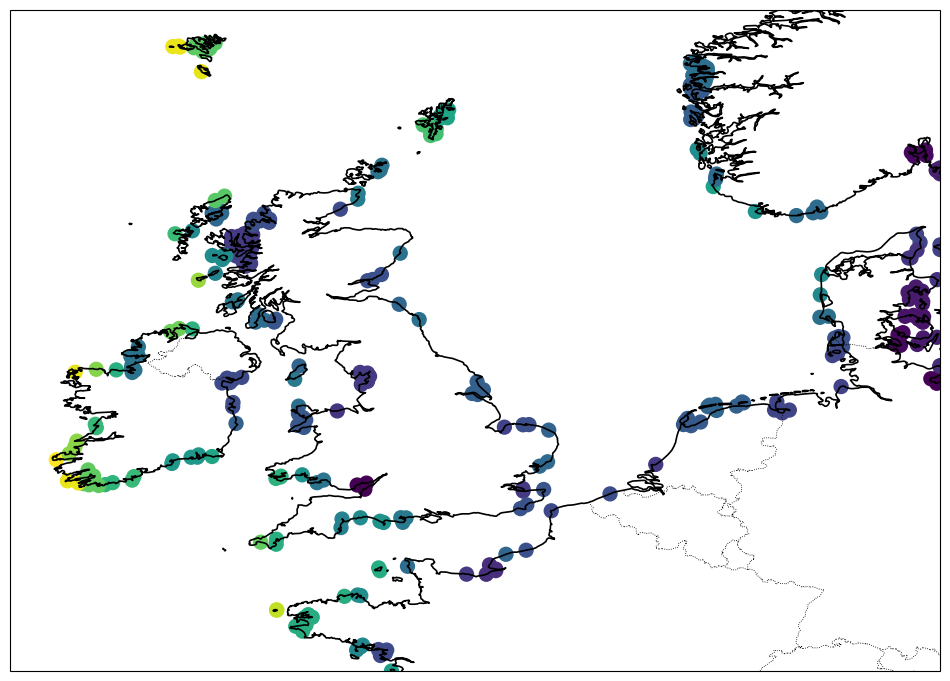

In [282]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Ensure datetime format
stats_df["time"] = pd.to_datetime(stats_df["time"])

# Select the first date in the dataset
first_date = stats_df["time"].max()

# Filter dataframe
df_first = stats_df[stats_df["time"] == first_date]

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linestyle=":", linewidth=0.6)

ax.scatter(
    df_first["lon"],
    df_first["lat"],
    c=df_first["swh"],
    s=100,
    transform=ccrs.PlateCarree()
)

plt.show()

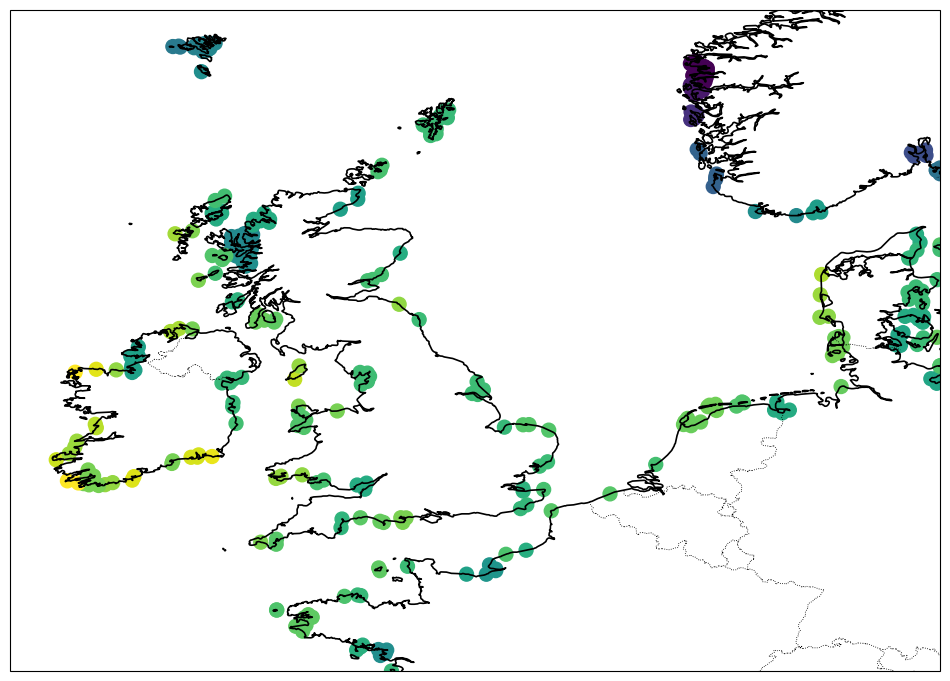

In [270]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linestyle=":", linewidth=0.6)

ax.scatter(
    save_df2["lon"],
    save_df2["lat"],
    c=save_df2["u10"],
    s=100,
    transform=ccrs.PlateCarree()
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=1.2)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linestyle=":", linewidth=0.6)

ax.scatter(
    save_df2["lon"],
    save_df2["lat"],
    c=save_df2["u10"],
    s=100,
    transform=ccrs.PlateCarree()
)

plt.show()

In [188]:
status_cols = [c for c in save_df2.columns if "status" in c]

save_df2 = save_df2.drop(columns=status_cols)

In [189]:
stats_df.to_csv("all_vars_combined.csv")


print(hoi)

In [182]:
save_df2["mwd_corridor_depth_max_m_10x10"]

0            NaN
1            NaN
2      -1.142857
3      -6.790395
4            NaN
          ...   
1706   -2.000000
1707   -1.043796
1708   -1.000000
1709         NaN
1710   -3.026895
Name: mwd_corridor_depth_max_m_10x10, Length: 1711, dtype: float64

In [ ]:
for i in save_df2.columns:
    print(i)

station
lon
lat
sea_lon
sea_lat
time
tp
u10
v10
d2m
t2m
msl
sst
sp
mwd
mwp
swh
wsk
number
expver
wind_magnitude
wind_dir
u10_abs
v10_abs
wind_wave_diff
wind_wave_alignment
tau_u
tau_u_abs
tau_v
tau_v_abs
tau_mag
wind_to_mean_deg
coastal_bearing_deg
coastal_radius_used_deg
bay_bearing_deg
bay_radius_used_deg
coastal_vs_bay_diff_deg
coastal_normal1_deg
coastal_normal2_deg
wind_vs_coastal_normal_diff_deg
wind_more_coastalshore_deg
bay_normal1_deg
bay_normal2_deg
wind_vs_bay_normal_diff_deg
wind_more_bayshore_deg
bearing_deg_0.1x0.1
depth_change_m_0.1x0.1
slope_mpm_0.1x0.1
slope_deg_0.1x0.1
local_slope_mean_mpm_0.1x0.1
local_slope_median_mpm_0.1x0.1
local_slope_std_mpm_0.1x0.1
local_slope_min_mpm_0.1x0.1
local_slope_max_mpm_0.1x0.1
local_slope_abs_mean_mpm_0.1x0.1
local_slope_abs_max_mpm_0.1x0.1
local_slope_angle_mean_deg_0.1x0.1
local_slope_angle_median_deg_0.1x0.1
local_slope_angle_std_deg_0.1x0.1
local_slope_angle_max_deg_0.1x0.1
max_sudden_drop_slope_deg_0.1x0.1
max_sudden_drop_slope_d

In [ ]:
import os
import xarray as xr
import pandas as pd

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

latlon = stats_df[["lat", "lon"]]
# if you want unique lat/lon pairs:
unique_latlon = latlon.drop_duplicates().to_numpy()

In [ ]:
import pandas as pd
#from build_directional_metrics import build_save_df2, save_save_df2

save_df2 = build_save_df2(
    stats_df=stats_df,
    tile_lookup=tile_lookup,
    merged_stats_df=stats_df[:1],   # or None if you only want directional metrics
    sizes="3x3",                       # or ["0.1x0.1", "1x1", "3x3", "10x10"]
    station_col="station",
    lat_col="lat",
    lon_col="lon",
    wind_col="wind_dir",
    wave_col="mwd",
    directions_are_from=True,
    corridor_width_km=10.0,
    bin_size_m=1000.0,
    coarsen_before=True,
    target_n_points=1000,
    max_steps=300,
    min_alignment=-0.25,
    verbose=True,
)

save_save_df2(
    save_df2,
    "/Users/lb962/Documents/GitHub/ESL_stats/data/processed/all_numerical_vars_bearing.csv"
)

NameError: name 'tile_lookup' is not defined

In [ ]:
import os
import xarray as xr
import pandas as pd

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

latlon = stats_df[["lat", "lon"]]
# if you want unique lat/lon pairs:
unique_latlon = latlon.drop_duplicates().to_numpy()

In [ ]:
import numpy as np
import xarray as xr

def compute_slope_aspect(ds, var="elevation"):
    
    z = ds[var]

    # grid spacing in degrees
    dlat = float(abs(ds.lat.diff("lat").mean()))
    dlon = float(abs(ds.lon.diff("lon").mean()))

    # convert degrees → meters
    R = 6371000  # Earth radius
    lat_rad = np.deg2rad(ds.lat)

    dy = dlat * np.pi/180 * R
    dx = dlon * np.pi/180 * R * np.cos(lat_rad)

    # compute gradients
    dz_dlat = z.differentiate("lat") / dy
    dz_dlon = z.differentiate("lon") / dx

    # slope (radians → degrees)
    slope = np.arctan(np.sqrt(dz_dlat**2 + dz_dlon**2))
    slope_deg = np.rad2deg(slope)

    # aspect
    aspect = np.arctan2(-dz_dlon, dz_dlat)
    aspect_deg = (np.rad2deg(aspect) + 360) % 360

    return xr.Dataset({
        "slope_deg": slope_deg,
        "aspect_deg": aspect_deg
    })

terrain = compute_slope_aspect(GEBCO_ds)
GEBCO_ds = xr.merge([GEBCO_ds, terrain])

In [ ]:
roughness = GEBCO_ds.elevation.rolling(lat=5, lon=5, center=True).std()
GEBCO_ds["roughness"] = roughness

In [ ]:
# curvature and curvature in slope direction. pos: convex (ridge), neg: channel
d2z_dx2 = GEBCO_ds.elevation.differentiate("lon").differentiate("lon")
d2z_dy2 = GEBCO_ds.elevation.differentiate("lat").differentiate("lat")

GEBCO_ds["curvature"] = d2z_dx2 + d2z_dy2
GEBCO_ds["profile_curvature"] = d2z_dx2
# BPI value	terrain
#positive	ridge
#negative	valley
#~0	flat
def compute_bpi(ds, window=21):
    mean_z = ds.elevation.rolling(
        lat=window,
        lon=window,
        center=True
    ).mean()

    bpi = ds.elevation - mean_z
    return bpi
GEBCO_ds["bpi"] = compute_bpi(GEBCO_ds, window=21)

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:228: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


: 

In [ ]:
window = 21

mean = GEBCO_ds.bpi.rolling(lat=window, lon=window, center=True).mean()
std = GEBCO_ds.bpi.rolling(lat=window, lon=window, center=True).std()

GEBCO_ds["bpi_norm"] = (GEBCO_ds.bpi - mean) / std

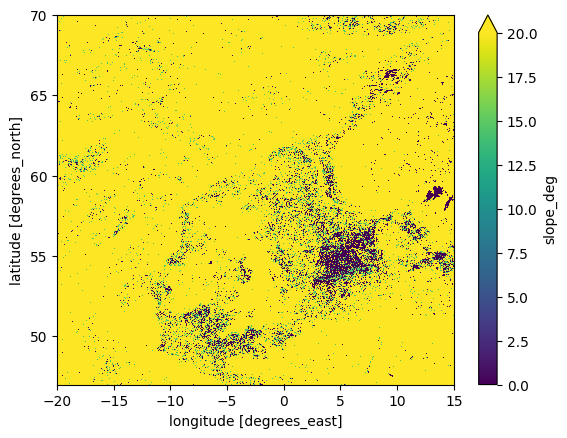

In [ ]:
GEBCO_ds.slope_deg.plot(vmin=0, vmax=20)

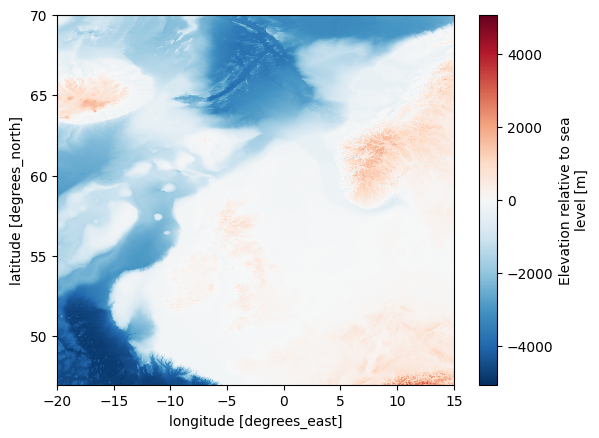

In [ ]:
GEBCO_ds.elevation.plot()

In [ ]:

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    ds_masked = ds_tile.copy()
    ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)
    return ds_masked

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2.0

    lat0, lat1 = lat - half, lat + half
    lon0, lon1 = lon - half, lon + half

    # Handle ascending/descending latitude
    if ds["lat"][0] < ds["lat"][-1]:
        lat_slice = slice(lat0, lat1)
    else:
        lat_slice = slice(lat1, lat0)

    # Handle ascending/descending longitude
    if ds["lon"][0] < ds["lon"][-1]:
        lon_slice = slice(lon0, lon1)
    else:
        lon_slice = slice(lon1, lon0)

    return ds.sel(lat=lat_slice, lon=lon_slice)

for lat, lon in unique_latlon:
    results["0.1x0.1"].append(extract_square(GEBCO_ds, lat, lon, 0.1))
    results["0.25x0.25"].append(extract_square(GEBCO_ds, lat, lon, 0.25))
    results["1x1"].append(extract_square(GEBCO_ds, lat, lon, 1))
    results["3x3"].append(extract_square(GEBCO_ds, lat, lon, 3))
    results["10x10"].append(extract_square(GEBCO_ds, lat, lon, 10))

KeyboardInterrupt: 

Plotting 3 tiles from 0.1x0.1


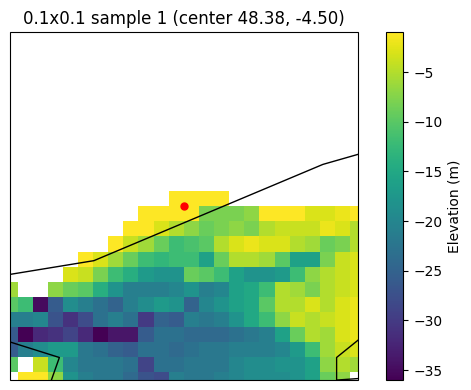

Skipping 0.1x0.1 tile 2: lat=0, lon=24


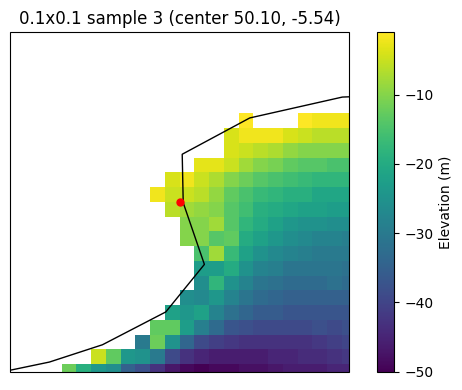

Plotting 3 tiles from 0.25x0.25


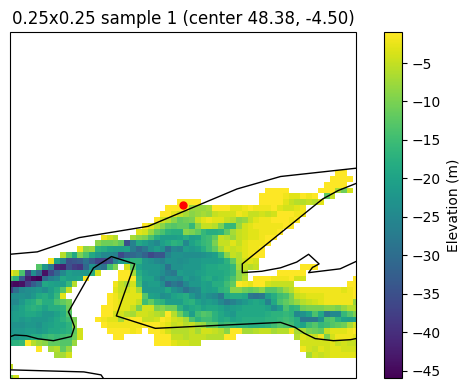

Skipping 0.25x0.25 tile 2: lat=0, lon=60


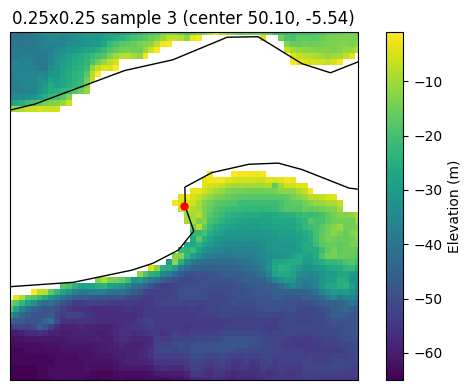

Plotting 3 tiles from 1x1


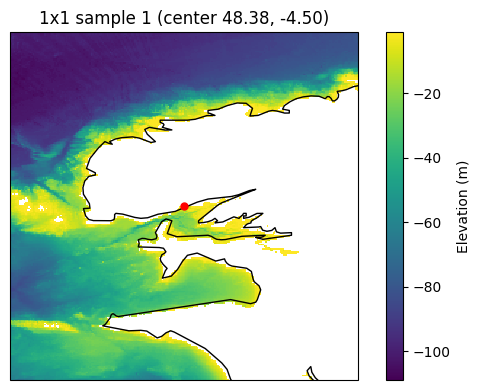

Skipping 1x1 tile 2: lat=0, lon=240


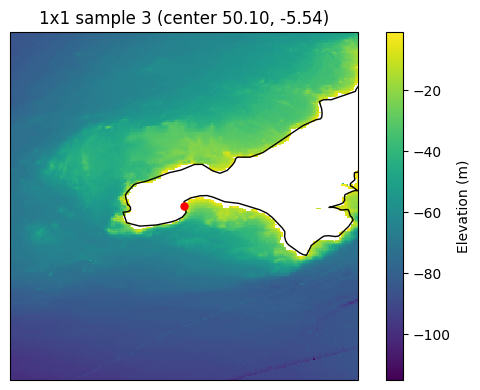

Plotting 3 tiles from 3x3


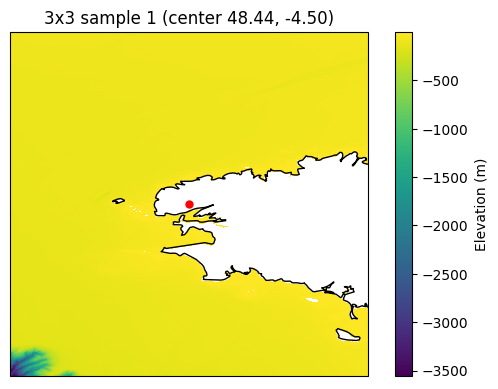

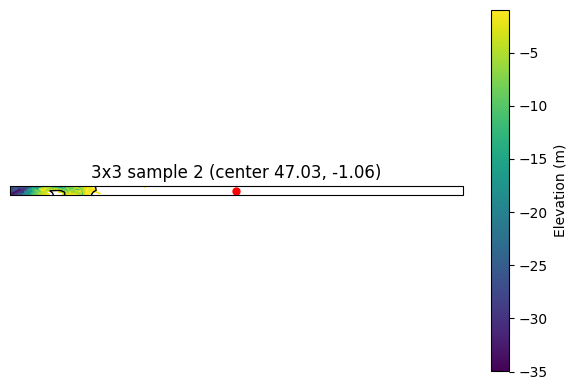

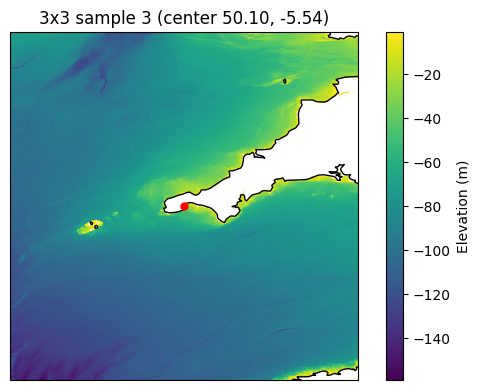

Plotting 3 tiles from 10x10


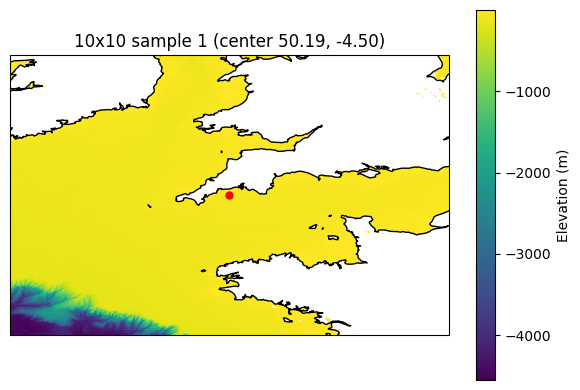

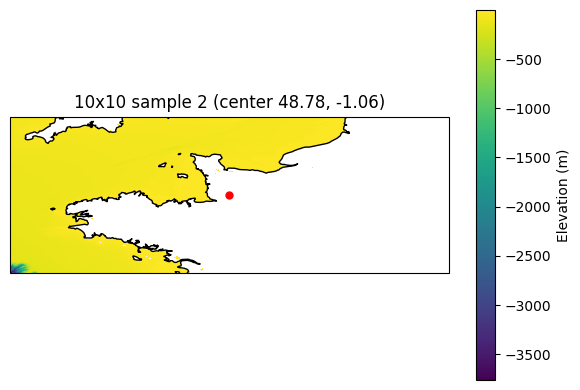

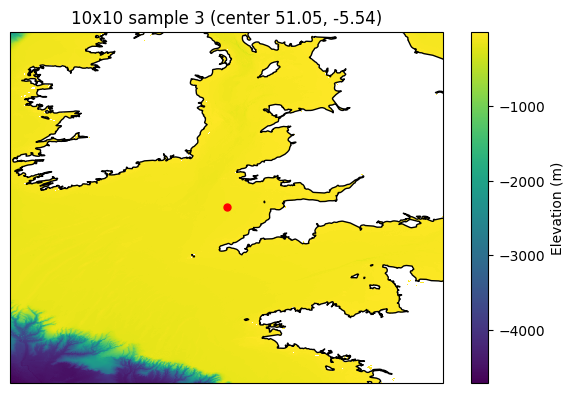

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_results_bathymetry(results, max_per_size=3):
    for key, tiles in results.items():
        if not tiles:
            print(f"No tiles in {key}")
            continue

        print(f"Plotting {min(len(tiles), max_per_size)} tiles from {key}")
        for i, ds_tile in enumerate(tiles[:max_per_size]):

            # mask shallow elevations
            ds_masked = ds_tile.copy()
            ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)

            # guard against empty/degenerate tiles
            lat_n = ds_masked.dims.get("lat", 0)
            lon_n = ds_masked.dims.get("lon", 0)
            if lat_n < 2 or lon_n < 2:
                print(f"Skipping {key} tile {i+1}: lat={lat_n}, lon={lon_n}")
                continue

            # tile center (coordinate midpoint, not necessarily station)
            center_lat = float(ds_masked["lat"].values.mean())
            center_lon = float(ds_masked["lon"].values.mean())

            fig = plt.figure(figsize=(6, 4))
            ax = plt.axes(projection=ccrs.PlateCarree())

            LON, LAT = np.meshgrid(ds_masked["lon"].values, ds_masked["lat"].values)
            Z = ds_masked["elevation"].values

            pcm = ax.pcolormesh(
                LON, LAT, Z,
                transform=ccrs.PlateCarree(),
                shading="auto"
            )

            ax.coastlines(resolution="10m")
            ax.set_extent(
                [float(ds_masked.lon.min()), float(ds_masked.lon.max()),
                 float(ds_masked.lat.min()), float(ds_masked.lat.max())],
                crs=ccrs.PlateCarree()
            )

            ax.set_title(f"{key} sample {i+1} (center {center_lat:.2f}, {center_lon:.2f})")
            ax.plot(center_lon, center_lat, "ro", markersize=5, transform=ccrs.PlateCarree())

            plt.colorbar(pcm, ax=ax, label="Elevation (m)")
            plt.tight_layout()
            plt.show()

# Example usage
plot_results_bathymetry(results, max_per_size=3)

In [ ]:
stats_df.lon.head()

0   -4.495
1   -4.495
2   -4.495
3   -4.495
4   -4.495
Name: lon, dtype: float64

near 0 wind is close to cross-shore/onshore

In [ ]:
stats_df.to_csv("DIff_GEV_station_variable_statistics.csv", index=False)

In [ ]:
import pandas as pd

def column_catalog(stats_df: pd.DataFrame) -> pd.DataFrame:
    cols = list(stats_df.columns)
    labels = pd.Series(index=cols, dtype="object")

    # ---- rules (in precedence order) ----

    # LOCATION
    for c in ("station", "lon", "lat"):
        if c in labels.index:
            labels.loc[c] = "LOCATION"

    # SEALEVEL_TARGET: anything containing "residual"
    residual_cols = [c for c in cols if "residual" in c.lower()]
    labels.loc[residual_cols] = "SEALEVEL_TARGET"

    # RELATIVE_BAY: anything with degrees
    deg_cols = [c for c in cols if c.endswith("_deg")]
    labels.loc[deg_cols] = "RELATIVE_BAY"

    # WEATHER: ERA5 vars + derivatives of those vars (e.g., u10_abs, tau_u_abs, etc.)
    era5_bases = ["u10", "v10", "d2m", "t2m", "msl", "sst", "sp", "tp", "mwd", "mwp", "swh"]
    weather_cols = []
    for c in cols:
        c_low = c.lower()
        if c in era5_bases:
            weather_cols.append(c)
            continue
        # derivatives like u10_abs, v10_abs, tp_something, etc.
        if any(c.startswith(base + "_") for base in era5_bases):
            weather_cols.append(c)
            continue
        # common derived-from-wind/wave diagnostics present in your df
        if c_low.startswith(("tau_", "wind_")) or c_low in ("wind_dir",):
            weather_cols.append(c)
            continue

    # Only set WEATHER where not already set by higher-precedence rules
    for c in weather_cols:
        if pd.isna(labels.loc[c]):
            labels.loc[c] = "WEATHER"

    # everything else
    labels = labels.fillna("OTHER")

    # return a tidy table "next to" the column names
    return pd.DataFrame({"column": labels.index, "label": labels.values})


# usage
catalog_df = column_catalog(stats_df)